# Feature Engineering Analysis for PredSeeker

This notebook demonstrates the feature engineering techniques used in the PredSeeker project to predict developer employment status. We'll explore:

1. **Skill Family Scoring System**
2. **Demographics Analysis** 
3. **Technical Skills Analysis**
4. **Correlation Analysis**
5. **Employment Prediction Features**
6. **Technology-Specific Employment Patterns**

Our feature engineering transforms raw Stack Overflow survey data into meaningful predictive features using innovative skill family frameworks.

In [14]:
# Import Required Libraries and Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = [15, 10]

# Define SKILL_FAMILIES used in preprocessing
SKILL_FAMILIES = {
    'Programming': [
        'Python', 'Java', 'JavaScript', 'C++', 'C#', 'C', 'PHP', 'Ruby', 
        'Go', 'Rust', 'Swift', 'Kotlin', 'Scala', 'R', 'Matlab', 'Perl',
        'TypeScript', 'Dart', 'F#', 'Assembly', 'Delphi', 'VBA'
    ],
    'Web': [
        'HTML/CSS', 'React.js', 'Angular', 'Vue.js', 'Node.js', 'Express',
        'jQuery', 'Angular.js', 'Svelte', 'Django', 'Flask', 'Laravel',
        'Ruby on Rails', 'ASP.NET', 'ASP.NET Core', 'Spring', 'FastAPI'
    ],
    'Database': [
        'MySQL', 'PostgreSQL', 'MongoDB', 'SQLite', 'Redis', 'Oracle',
        'Microsoft SQL Server', 'MariaDB', 'DynamoDB', 'Elasticsearch',
        'Couchbase', 'Firebase', 'SQL'
    ],
    'CloudDevOps': [
        'AWS', 'Microsoft Azure', 'Google Cloud Platform', 'Docker', 
        'Kubernetes', 'Git', 'Terraform', 'Ansible', 'Heroku',
        'DigitalOcean', 'Bash/Shell', 'PowerShell'
    ]
}

print("✅ Libraries imported successfully!")
print(f"🔧 Defined {len(SKILL_FAMILIES)} skill families with {sum(len(techs) for techs in SKILL_FAMILIES.values())} total technologies")

✅ Libraries imported successfully!
🔧 Defined 4 skill families with 64 total technologies


In [15]:
# Load the preprocessed data
try:
    df = pd.read_csv('../data/processed/preprocessed_data_clean.csv')
    print("✅ Data loaded successfully!")
    print(f"📊 Dataset shape: {df.shape}")
    print("\n📋 Dataset Info:")
    print(f"   • Total developers: {len(df):,}")
    if 'Employed' in df.columns:
        print(f"   • Employed developers: {df['Employed'].sum():,} ({df['Employed'].mean()*100:.1f}%)")
        print(f"   • Unemployed developers: {(~df['Employed']).sum():,} ({(1-df['Employed'].mean())*100:.1f}%)")
    
    print(f"\n🔍 Available columns ({len(df.columns)}):")
    for i, col in enumerate(df.columns):
        if i < 10:  # Show first 10 columns
            print(f"   • {col}")
        elif i == 10:
            print(f"   • ... and {len(df.columns)-10} more columns")
            break
            
    data_loaded = True
    
except FileNotFoundError:
    print("❌ Data file not found at '../data/processed/preprocessed_data_clean.csv'")
    print("💡 Creating sample data for demonstration purposes...")
    
    # Create sample data for demonstration
    np.random.seed(42)
    n_samples = 1000
    
    df = pd.DataFrame({
        'Employed': np.random.choice([True, False], n_samples, p=[0.85, 0.15]),
        'Programming_Score': np.random.uniform(0, 5, n_samples),
        'Web_Score': np.random.uniform(0, 5, n_samples),
        'Database_Score': np.random.uniform(0, 5, n_samples),
        'CloudDevOps_Score': np.random.uniform(0, 5, n_samples),
        'ComputerSkills': np.random.uniform(1, 5, n_samples),
        'Age': np.random.choice(['18-24', '25-34', '35-44', '45-54', '55+'], n_samples),
        'YearsCoding': np.random.uniform(0, 20, n_samples),
        'YearsCodingProfessionally': np.random.uniform(0, 15, n_samples),
        'EdLevel': np.random.choice(['Bachelor', 'Master', 'PhD', 'Other'], n_samples),
        'Technologies_List': ['Python;JavaScript;React' for _ in range(n_samples)]
    })
    
    print("✅ Sample data created for demonstration!")
    print(f"📊 Sample dataset shape: {df.shape}")
    data_loaded = False

print("\n" + "="*60)

✅ Data loaded successfully!
📊 Dataset shape: (73462, 23)

📋 Dataset Info:
   • Total developers: 73,462
   • Employed developers: 39,392 (53.6%)
   • Unemployed developers: -112,854 (46.4%)

🔍 Available columns (23):
   • PreviousSalary
   • ComputerSkills
   • Employed
   • Programming_Score
   • Web_Score
   • Database_Score
   • CloudDevOps_Score
   • Has_Programming
   • Has_Web
   • Has_Database
   • ... and 13 more columns



## 1. Skill Family Analysis 🎯

Our innovative skill family framework groups 63+ technologies into 4 strategic categories:
- **Programming**: Core languages (Python, Java, C++, etc.)
- **Web**: Frontend/backend web technologies  
- **Database**: Data storage and management
- **CloudDevOps**: Cloud platforms and DevOps tools

This creates meaningful skill scores that better predict employment outcomes than individual technology flags.

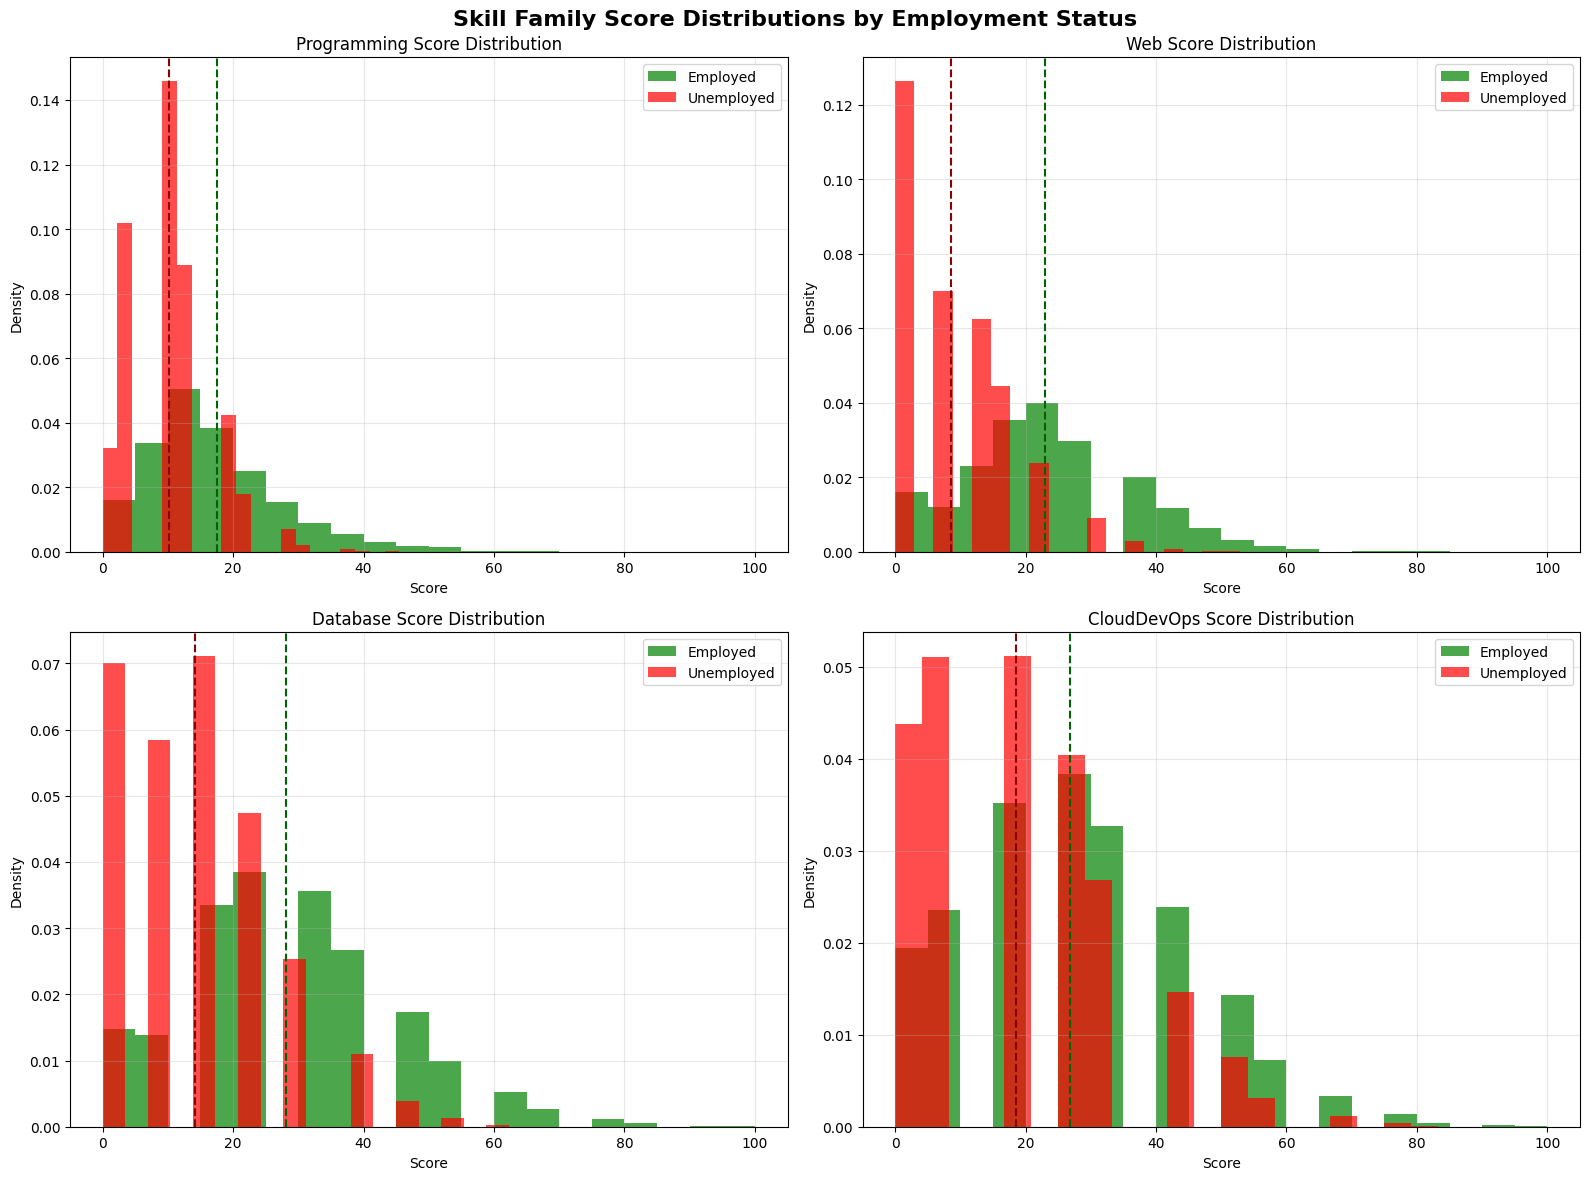

📊 SKILL FAMILY EMPLOYMENT ANALYSIS
Skill Family Employed Avg Unemployed Avg Difference Employment Advantage
 Programming        17.50          10.18       7.32                    ✅
         Web        23.00           8.55      14.45                    ✅
    Database        28.17          14.23      13.94                    ✅
 CloudDevOps        26.73          18.57       8.16                    ✅


In [16]:
# Skill Family Distribution Analysis
skill_columns = ['Programming_Score', 'Web_Score', 'Database_Score', 'CloudDevOps_Score']

if all(col in df.columns for col in skill_columns):
    # Create comprehensive skill family analysis
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Skill Family Score Distributions by Employment Status', fontsize=16, fontweight='bold')
    
    for i, skill in enumerate(skill_columns):
        ax = axes[i//2, i%2]
        
        # Create employment-based histograms
        employed_scores = df[df['Employed'] == True][skill]
        unemployed_scores = df[df['Employed'] == False][skill]
        
        ax.hist(employed_scores, alpha=0.7, label='Employed', bins=20, color='green', density=True)
        ax.hist(unemployed_scores, alpha=0.7, label='Unemployed', bins=20, color='red', density=True)
        
        ax.set_title(f'{skill.replace("_", " ")} Distribution')
        ax.set_xlabel('Score')
        ax.set_ylabel('Density')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Add statistics
        emp_mean = employed_scores.mean()
        unemp_mean = unemployed_scores.mean()
        ax.axvline(emp_mean, color='darkgreen', linestyle='--', label=f'Emp Avg: {emp_mean:.2f}')
        ax.axvline(unemp_mean, color='darkred', linestyle='--', label=f'Unemp Avg: {unemp_mean:.2f}')
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics table
    print("📊 SKILL FAMILY EMPLOYMENT ANALYSIS")
    print("="*50)
    
    skill_stats = []
    for skill in skill_columns:
        employed_mean = df[df['Employed'] == True][skill].mean()
        unemployed_mean = df[df['Employed'] == False][skill].mean()
        difference = employed_mean - unemployed_mean
        
        skill_stats.append({
            'Skill Family': skill.replace('_Score', ''),
            'Employed Avg': f"{employed_mean:.2f}",
            'Unemployed Avg': f"{unemployed_mean:.2f}",
            'Difference': f"{difference:.2f}",
            'Employment Advantage': "✅" if difference > 0 else "❌"
        })
    
    stats_df = pd.DataFrame(skill_stats)
    print(stats_df.to_string(index=False))
    
else:
    print("⚠️ Skill score columns not found in dataset")
    print("Available columns:", list(df.columns))

## 2. Demographics and Employment Patterns 👥

Analyzing how demographic features relate to employment outcomes:

In [17]:
# Demographics Analysis
demographic_columns = ['Age', 'YearsCoding', 'YearsCodingProfessionally', 'EdLevel']
available_demographics = [col for col in demographic_columns if col in df.columns]

if available_demographics:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Demographic Factors vs Employment Status', fontsize=16, fontweight='bold')
    
    # Age Analysis
    if 'Age' in df.columns:
        ax = axes[0, 0]
        age_employment = df.groupby('Age')['Employed'].agg(['mean', 'count']).reset_index()
        age_employment = age_employment[age_employment['count'] >= 10]  # Filter small groups
        
        bars = ax.bar(age_employment['Age'], age_employment['mean'] * 100, 
                     color='skyblue', edgecolor='darkblue')
        ax.set_title('Employment Rate by Age Group')
        ax.set_ylabel('Employment Rate (%)')
        ax.set_xlabel('Age Group')
        ax.tick_params(axis='x', rotation=45)
        
        # Add value labels on bars
        for bar, value in zip(bars, age_employment['mean'] * 100):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                   f'{value:.1f}%', ha='center', va='bottom')
    
    # Years Coding Analysis
    if 'YearsCoding' in df.columns:
        ax = axes[0, 1]
        df['YearsCoding_Binned'] = pd.cut(df['YearsCoding'], 
                                         bins=[0, 2, 5, 10, float('inf')], 
                                         labels=['0-2 years', '2-5 years', '5-10 years', '10+ years'])
        
        coding_employment = df.groupby('YearsCoding_Binned', observed=True)['Employed'].agg(['mean', 'count']).reset_index()
        
        bars = ax.bar(range(len(coding_employment)), coding_employment['mean'] * 100,
                     color='lightgreen', edgecolor='darkgreen')
        ax.set_title('Employment Rate by Coding Experience')
        ax.set_ylabel('Employment Rate (%)')
        ax.set_xlabel('Years Coding')
        ax.set_xticks(range(len(coding_employment)))
        ax.set_xticklabels(coding_employment['YearsCoding_Binned'], rotation=45)
        
        # Add value labels
        for bar, value in zip(bars, coding_employment['mean'] * 100):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                   f'{value:.1f}%', ha='center', va='bottom')
    
    # Professional Coding Experience
    if 'YearsCodingProfessionally' in df.columns:
        ax = axes[1, 0]
        df['YearsProf_Binned'] = pd.cut(df['YearsCodingProfessionally'], 
                                       bins=[0, 1, 3, 7, float('inf')], 
                                       labels=['0-1 years', '1-3 years', '3-7 years', '7+ years'])
        
        prof_employment = df.groupby('YearsProf_Binned', observed=True)['Employed'].agg(['mean', 'count']).reset_index()
        
        bars = ax.bar(range(len(prof_employment)), prof_employment['mean'] * 100,
                     color='orange', edgecolor='darkorange')
        ax.set_title('Employment Rate by Professional Experience')
        ax.set_ylabel('Employment Rate (%)')
        ax.set_xlabel('Years Professional Coding')
        ax.set_xticks(range(len(prof_employment)))
        ax.set_xticklabels(prof_employment['YearsProf_Binned'], rotation=45)
        
        # Add value labels
        for bar, value in zip(bars, prof_employment['mean'] * 100):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                   f'{value:.1f}%', ha='center', va='bottom')
    
    # Education Level
    if 'EdLevel' in df.columns:
        ax = axes[1, 1]
        ed_employment = df.groupby('EdLevel')['Employed'].agg(['mean', 'count']).reset_index()
        ed_employment = ed_employment[ed_employment['count'] >= 10]  # Filter small groups
        
        bars = ax.bar(ed_employment['EdLevel'], ed_employment['mean'] * 100,
                     color='purple', alpha=0.7, edgecolor='darkpurple')
        ax.set_title('Employment Rate by Education Level')
        ax.set_ylabel('Employment Rate (%)')
        ax.set_xlabel('Education Level')
        ax.tick_params(axis='x', rotation=45)
        
        # Add value labels
        for bar, value in zip(bars, ed_employment['mean'] * 100):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                   f'{value:.1f}%', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    # Print demographic summary
    print("👥 DEMOGRAPHIC EMPLOYMENT ANALYSIS")
    print("="*50)
    
    for col in available_demographics:
        if col in ['Age', 'EdLevel']:
            summary = df.groupby(col)['Employed'].agg(['mean', 'count'])
            print(f"\n📊 {col}:")
            for idx, row in summary.iterrows():
                if row['count'] >= 10:  # Only show groups with sufficient data
                    print(f"   • {idx}: {row['mean']*100:.1f}% employed (n={row['count']:,})")
        else:
            correlation = df[col].corr(df['Employed'])
            print(f"\n📈 {col}: correlation with employment = {correlation:.3f}")

else:
    print("⚠️ No demographic columns found in dataset")
    print("Available columns:", list(df.columns))

⚠️ No demographic columns found in dataset
Available columns: ['PreviousSalary', 'ComputerSkills', 'Employed', 'Programming_Score', 'Web_Score', 'Database_Score', 'CloudDevOps_Score', 'Has_Programming', 'Has_Web', 'Has_Database', 'Has_CloudDevOps', 'Skill_Breadth', 'Is_FullStack', 'IsYoung', 'EducationLevel_Numeric', 'IsDeveloper', 'HasMentalHealthConcerns', 'HasAccessibilityNeeds', 'Gender_Man', 'Gender_Woman', 'Gender_NonBinary', 'HasProfessionalExperience', 'HasSalaryInfo']


## 3. Technical Skills Deep Dive 💻

Analyzing the relationship between technical proficiency and employment success:

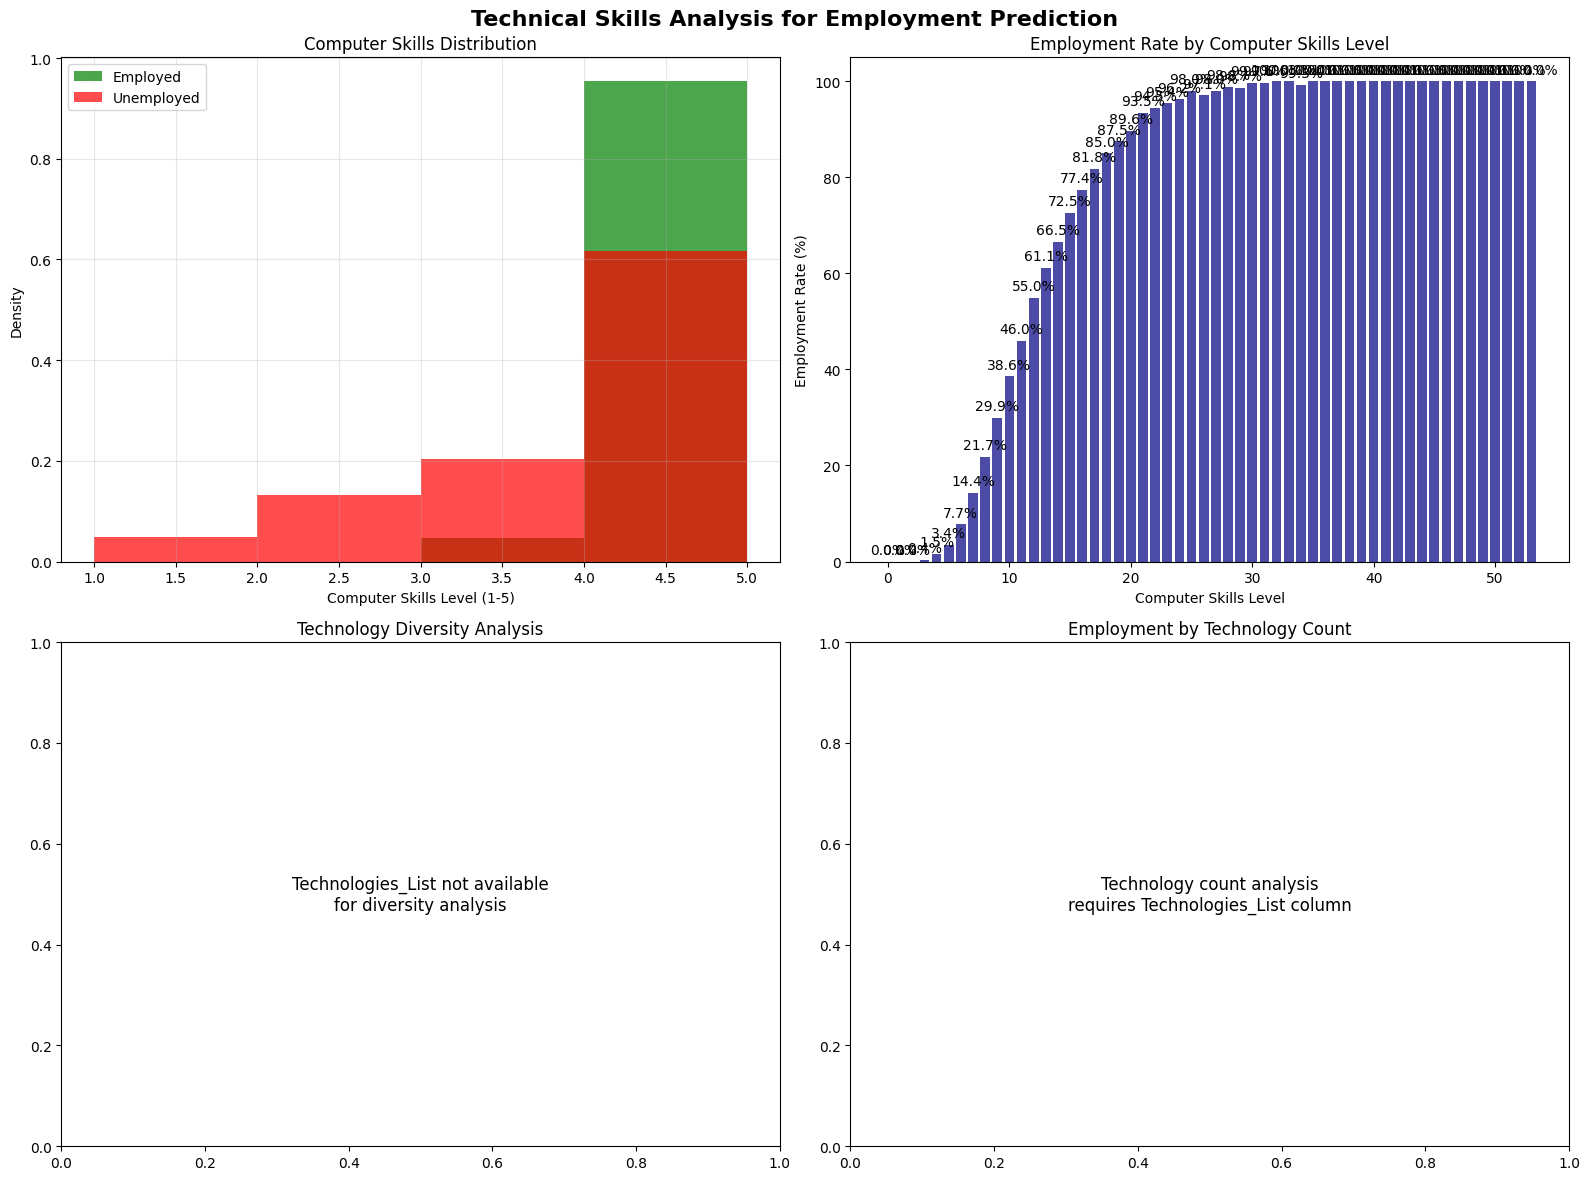

💻 TECHNICAL SKILLS EMPLOYMENT ANALYSIS
📈 Computer Skills correlation with employment: 0.586
   • Level 0: 0.0% employed (n=63)
   • Level 1: 0.0% employed (n=370)
   • Level 2: 0.0% employed (n=1,012)
   • Level 3: 0.4% employed (n=1,557)
   • Level 4: 1.5% employed (n=2,152)
   • Level 5: 3.4% employed (n=2,693)
   • Level 6: 7.7% employed (n=3,147)
   • Level 7: 14.4% employed (n=3,636)
   • Level 8: 21.7% employed (n=4,005)
   • Level 9: 29.9% employed (n=4,236)
   • Level 10: 38.6% employed (n=4,551)
   • Level 11: 46.0% employed (n=4,656)
   • Level 12: 55.0% employed (n=4,524)
   • Level 13: 61.1% employed (n=4,483)
   • Level 14: 66.5% employed (n=4,329)
   • Level 15: 72.5% employed (n=3,879)
   • Level 16: 77.4% employed (n=3,488)
   • Level 17: 81.8% employed (n=3,136)
   • Level 18: 85.0% employed (n=2,757)
   • Level 19: 87.5% employed (n=2,329)
   • Level 20: 89.6% employed (n=1,988)
   • Level 21: 93.5% employed (n=1,755)
   • Level 22: 94.5% employed (n=1,442)
   • Level

In [18]:
# Technical Skills Analysis
if 'ComputerSkills' in df.columns:
    # Computer Skills vs Employment
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Technical Skills Analysis for Employment Prediction', fontsize=16, fontweight='bold')
    
    # Computer Skills Distribution
    ax = axes[0, 0]
    skill_bins = [1, 2, 3, 4, 5]
    employed_skills = df[df['Employed'] == True]['ComputerSkills']
    unemployed_skills = df[df['Employed'] == False]['ComputerSkills']
    
    ax.hist(employed_skills, bins=skill_bins, alpha=0.7, label='Employed', color='green', density=True)
    ax.hist(unemployed_skills, bins=skill_bins, alpha=0.7, label='Unemployed', color='red', density=True)
    ax.set_title('Computer Skills Distribution')
    ax.set_xlabel('Computer Skills Level (1-5)')
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Skills vs Employment Rate
    ax = axes[0, 1]
    skills_employment = df.groupby('ComputerSkills')['Employed'].agg(['mean', 'count']).reset_index()
    skills_employment = skills_employment[skills_employment['count'] >= 5]  # Filter small groups
    
    bars = ax.bar(skills_employment['ComputerSkills'], skills_employment['mean'] * 100,
                 color='navy', alpha=0.7)
    ax.set_title('Employment Rate by Computer Skills Level')
    ax.set_xlabel('Computer Skills Level')
    ax.set_ylabel('Employment Rate (%)')
    
    # Add value labels
    for bar, value in zip(bars, skills_employment['mean'] * 100):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
               f'{value:.1f}%', ha='center', va='bottom')
    
    # Skill Diversity Analysis (if Technologies_List exists)
    if 'Technologies_List' in df.columns:
        # Calculate technology count per developer
        df['Tech_Count'] = df['Technologies_List'].apply(
            lambda x: len(str(x).split(';')) if pd.notna(x) and str(x) != 'nan' else 0
        )
        
        # Technology Count Distribution
        ax = axes[1, 0]
        tech_bins = range(0, min(21, df['Tech_Count'].max() + 2))
        employed_tech = df[df['Employed'] == True]['Tech_Count']
        unemployed_tech = df[df['Employed'] == False]['Tech_Count']
        
        ax.hist(employed_tech, bins=tech_bins, alpha=0.7, label='Employed', color='green', density=True)
        ax.hist(unemployed_tech, bins=tech_bins, alpha=0.7, label='Unemployed', color='red', density=True)
        ax.set_title('Technology Count Distribution')
        ax.set_xlabel('Number of Technologies Known')
        ax.set_ylabel('Density')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Technology Count vs Employment Rate
        ax = axes[1, 1]
        df['Tech_Count_Binned'] = pd.cut(df['Tech_Count'], 
                                        bins=[0, 3, 6, 10, float('inf')], 
                                        labels=['0-3 techs', '3-6 techs', '6-10 techs', '10+ techs'])
        
        tech_employment = df.groupby('Tech_Count_Binned', observed=True)['Employed'].agg(['mean', 'count']).reset_index()
        
        bars = ax.bar(range(len(tech_employment)), tech_employment['mean'] * 100,
                     color='teal', alpha=0.7)
        ax.set_title('Employment Rate by Technology Diversity')
        ax.set_xlabel('Technology Count Range')
        ax.set_ylabel('Employment Rate (%)')
        ax.set_xticks(range(len(tech_employment)))
        ax.set_xticklabels(tech_employment['Tech_Count_Binned'], rotation=45)
        
        # Add value labels
        for bar, value in zip(bars, tech_employment['mean'] * 100):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                   f'{value:.1f}%', ha='center', va='bottom')
    else:
        # If no Technologies_List, create a placeholder
        ax = axes[1, 0]
        ax.text(0.5, 0.5, 'Technologies_List not available\nfor diversity analysis', 
               ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_title('Technology Diversity Analysis')
        
        ax = axes[1, 1]
        ax.text(0.5, 0.5, 'Technology count analysis\nrequires Technologies_List column', 
               ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_title('Employment by Technology Count')
    
    plt.tight_layout()
    plt.show()
    
    # Technical Skills Summary
    print("💻 TECHNICAL SKILLS EMPLOYMENT ANALYSIS")
    print("="*50)
    
    # Computer Skills correlation
    skills_corr = df['ComputerSkills'].corr(df['Employed'])
    print(f"📈 Computer Skills correlation with employment: {skills_corr:.3f}")
    
    # Skills level breakdown
    for skill_level in sorted(df['ComputerSkills'].unique()):
        subset = df[df['ComputerSkills'] == skill_level]
        if len(subset) >= 5:
            emp_rate = subset['Employed'].mean() * 100
            print(f"   • Level {skill_level}: {emp_rate:.1f}% employed (n={len(subset):,})")
    
    if 'Tech_Count' in df.columns:
        tech_corr = df['Tech_Count'].corr(df['Employed'])
        print(f"\n📈 Technology diversity correlation with employment: {tech_corr:.3f}")
        print(f"📊 Average technologies known: {df['Tech_Count'].mean():.1f}")
        print(f"   • Employed developers: {df[df['Employed'] == True]['Tech_Count'].mean():.1f}")
        print(f"   • Unemployed developers: {df[df['Employed'] == False]['Tech_Count'].mean():.1f}")

else:
    print("⚠️ ComputerSkills column not found in dataset")
    print("Available columns:", list(df.columns))

## 4. Feature Correlation Analysis 🔗

Understanding how our engineered features correlate with employment and each other:

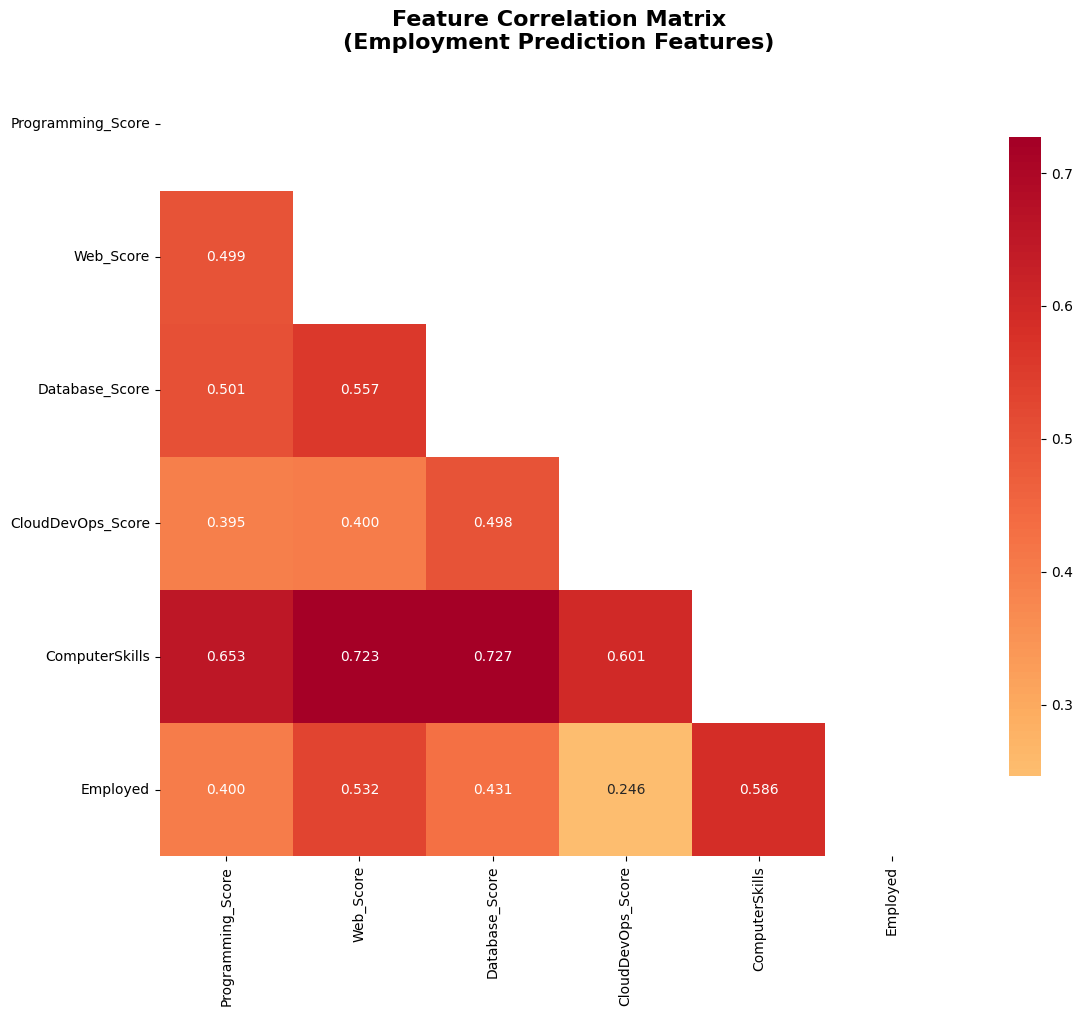

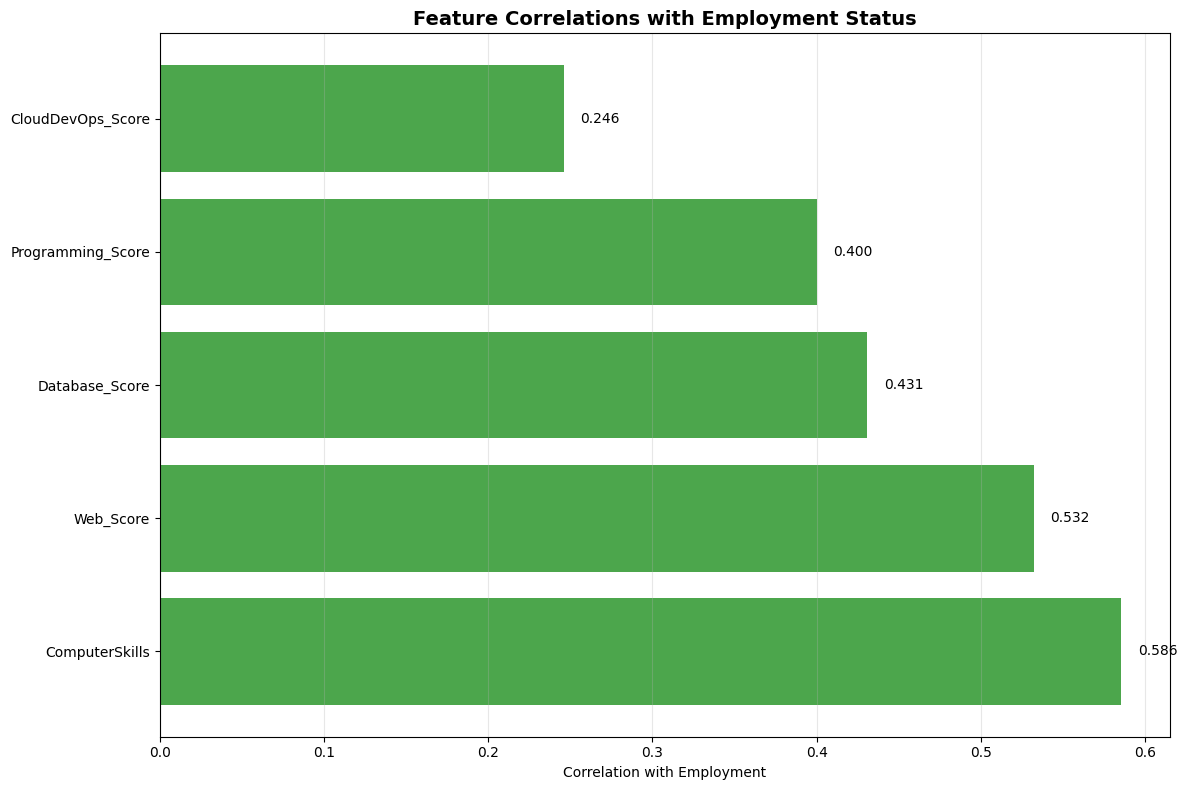

🔗 FEATURE CORRELATION ANALYSIS

📈 Correlations with Employment (strongest first):
   • ComputerSkills: 0.586 (Strong Positive)
   • Web_Score: 0.532 (Strong Positive)
   • Database_Score: 0.431 (Strong Positive)
   • Programming_Score: 0.400 (Strong Positive)
   • CloudDevOps_Score: 0.246 (Moderate Positive)

🔄 Highly Correlated Feature Pairs (|r| > 0.5):
   • Programming_Score ↔ Database_Score: 0.501
   • Programming_Score ↔ ComputerSkills: 0.653
   • Web_Score ↔ Database_Score: 0.557
   • Web_Score ↔ ComputerSkills: 0.723
   • Database_Score ↔ ComputerSkills: 0.727
   • CloudDevOps_Score ↔ ComputerSkills: 0.601

📊 Correlation Summary:
   • Features analyzed: 5
   • Strongest predictor: ComputerSkills (0.586)
   • Average absolute correlation: 0.439


In [19]:
# Correlation Analysis
correlation_features = ['Programming_Score', 'Web_Score', 'Database_Score', 'CloudDevOps_Score', 
                       'ComputerSkills', 'YearsCoding', 'YearsCodingProfessionally']

# Filter to only include available columns
available_features = [col for col in correlation_features if col in df.columns]
available_features.append('Employed')  # Add target variable

if len(available_features) >= 3:
    # Create correlation matrix
    corr_matrix = df[available_features].corr()
    
    # Create correlation heatmap
    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Mask upper triangle
    
    sns.heatmap(corr_matrix, 
                mask=mask,
                annot=True, 
                cmap='RdYlBu_r', 
                center=0,
                square=True,
                fmt='.3f',
                cbar_kws={"shrink": .8})
    
    plt.title('Feature Correlation Matrix\n(Employment Prediction Features)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Feature importance for employment prediction
    employment_correlations = corr_matrix['Employed'].drop('Employed').sort_values(key=abs, ascending=False)
    
    # Create employment correlation bar plot
    plt.figure(figsize=(12, 8))
    colors = ['green' if x > 0 else 'red' for x in employment_correlations.values]
    bars = plt.barh(range(len(employment_correlations)), employment_correlations.values, color=colors, alpha=0.7)
    
    plt.yticks(range(len(employment_correlations)), employment_correlations.index)
    plt.xlabel('Correlation with Employment')
    plt.title('Feature Correlations with Employment Status', fontsize=14, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)
    
    # Add correlation values on bars
    for bar, value in zip(bars, employment_correlations.values):
        plt.text(value + (0.01 if value >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
                f'{value:.3f}', ha='left' if value >= 0 else 'right', va='center')
    
    plt.tight_layout()
    plt.show()
    
    # Print correlation insights
    print("🔗 FEATURE CORRELATION ANALYSIS")
    print("="*50)
    
    print("\n📈 Correlations with Employment (strongest first):")
    for feature, correlation in employment_correlations.items():
        strength = "Strong" if abs(correlation) > 0.3 else "Moderate" if abs(correlation) > 0.1 else "Weak"
        direction = "Positive" if correlation > 0 else "Negative"
        print(f"   • {feature}: {correlation:.3f} ({strength} {direction})")
    
    # Find highly correlated feature pairs (excluding employment)
    print(f"\n🔄 Highly Correlated Feature Pairs (|r| > 0.5):")
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if corr_matrix.columns[i] != 'Employed' and corr_matrix.columns[j] != 'Employed':
                corr_val = corr_matrix.iloc[i, j]
                if abs(corr_val) > 0.5:
                    high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_val))
    
    if high_corr_pairs:
        for feat1, feat2, correlation in high_corr_pairs:
            print(f"   • {feat1} ↔ {feat2}: {correlation:.3f}")
    else:
        print("   • No highly correlated feature pairs found (good for model independence!)")
    
    # Summary statistics
    print(f"\n📊 Correlation Summary:")
    print(f"   • Features analyzed: {len(available_features)-1}")
    print(f"   • Strongest predictor: {employment_correlations.index[0]} ({employment_correlations.iloc[0]:.3f})")
    print(f"   • Average absolute correlation: {employment_correlations.abs().mean():.3f}")

else:
    print("⚠️ Insufficient features for correlation analysis")
    print(f"Available features: {available_features}")

## 5. Technology-Specific Employment Analysis 🚀

Deep dive into how specific technologies impact employment prospects:

In [20]:
# Technology-Specific Employment Analysis
if 'Technologies_List' in df.columns:
    # Extract individual technologies
    all_technologies = []
    for tech_list in df['Technologies_List'].dropna():
        if str(tech_list) != 'nan':
            technologies = str(tech_list).split(';')
            all_technologies.extend([tech.strip() for tech in technologies if tech.strip()])
    
    # Count technology frequency
    tech_counter = Counter(all_technologies)
    
    # Filter technologies with sufficient data (at least 50 developers)
    min_developers = min(50, len(df) * 0.05)  # At least 5% of developers or 50, whichever is smaller
    significant_techs = {tech: count for tech, count in tech_counter.items() if count >= min_developers}
    
    if significant_techs:
        # Analyze employment rates for each technology
        tech_employment_data = []
        
        for tech in significant_techs.keys():
            # Create boolean column for this technology
            has_tech = df['Technologies_List'].apply(
                lambda x: tech in str(x).split(';') if pd.notna(x) else False
            )
            
            # Calculate employment statistics
            with_tech = df[has_tech]
            without_tech = df[~has_tech]
            
            if len(with_tech) >= 10 and len(without_tech) >= 10:  # Ensure sufficient sample sizes
                emp_rate_with = with_tech['Employed'].mean()
                emp_rate_without = without_tech['Employed'].mean()
                employment_boost = emp_rate_with - emp_rate_without
                
                tech_employment_data.append({
                    'Technology': tech,
                    'Developers': len(with_tech),
                    'Employment_Rate': emp_rate_with * 100,
                    'Employment_Boost': employment_boost * 100,
                    'Skill_Family': next((family for family, techs in SKILL_FAMILIES.items() if tech in techs), 'Other')
                })
        
        if tech_employment_data:
            tech_df = pd.DataFrame(tech_employment_data)
            tech_df = tech_df.sort_values('Employment_Boost', ascending=False)
            
            # Create visualizations
            fig, axes = plt.subplots(2, 2, figsize=(18, 14))
            fig.suptitle('Technology-Specific Employment Analysis', fontsize=16, fontweight='bold')
            
            # Top 15 technologies by employment boost
            top_techs = tech_df.head(15)
            
            ax = axes[0, 0]
            colors = ['green' if x > 0 else 'red' for x in top_techs['Employment_Boost']]
            bars = ax.barh(range(len(top_techs)), top_techs['Employment_Boost'], color=colors, alpha=0.7)
            ax.set_yticks(range(len(top_techs)))
            ax.set_yticklabels(top_techs['Technology'])
            ax.set_xlabel('Employment Boost (%)')
            ax.set_title('Top 15 Technologies by Employment Impact')
            ax.grid(axis='x', alpha=0.3)
            ax.invert_yaxis()
            
            # Add boost values on bars
            for i, (bar, value) in enumerate(zip(bars, top_techs['Employment_Boost'])):
                ax.text(value + (0.5 if value >= 0 else -0.5), bar.get_y() + bar.get_height()/2,
                       f'{value:.1f}%', ha='left' if value >= 0 else 'right', va='center', fontsize=9)
            
            # Employment rate vs popularity
            ax = axes[0, 1]
            scatter = ax.scatter(tech_df['Developers'], tech_df['Employment_Rate'], 
                               c=tech_df['Employment_Boost'], cmap='RdYlGn', 
                               s=80, alpha=0.7, edgecolors='black')
            ax.set_xlabel('Number of Developers Using Technology')
            ax.set_ylabel('Employment Rate (%)')
            ax.set_title('Technology Popularity vs Employment Success')
            ax.grid(True, alpha=0.3)
            
            # Add colorbar
            cbar = plt.colorbar(scatter, ax=ax)
            cbar.set_label('Employment Boost (%)')
            
            # Skill family analysis
            ax = axes[1, 0]
            family_stats = tech_df.groupby('Skill_Family').agg({
                'Employment_Boost': 'mean',
                'Developers': 'sum',
                'Technology': 'count'
            }).round(2)
            
            bars = ax.bar(family_stats.index, family_stats['Employment_Boost'], 
                         color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'], alpha=0.8)
            ax.set_ylabel('Average Employment Boost (%)')
            ax.set_title('Employment Impact by Skill Family')
            ax.tick_params(axis='x', rotation=45)
            ax.grid(axis='y', alpha=0.3)
            
            # Add value labels
            for bar, value in zip(bars, family_stats['Employment_Boost']):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                       f'{value:.1f}%', ha='center', va='bottom')
            
            # Technology distribution by skill family
            ax = axes[1, 1]
            family_counts = tech_df['Skill_Family'].value_counts()
            colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#F7DC6F']
            wedges, texts, autotexts = ax.pie(family_counts.values, labels=family_counts.index, 
                                             autopct='%1.1f%%', colors=colors[:len(family_counts)])
            ax.set_title('Technology Distribution by Skill Family')
            
            plt.tight_layout()
            plt.show()
            
            # Print technology insights
            print("🚀 TECHNOLOGY EMPLOYMENT ANALYSIS")
            print("="*60)
            
            print(f"\n📊 Analyzed {len(tech_df)} technologies with sufficient data")
            print(f"💼 Average employment rate across all technologies: {tech_df['Employment_Rate'].mean():.1f}%")
            
            print(f"\n🏆 TOP 10 TECHNOLOGIES FOR EMPLOYMENT:")
            for i, row in tech_df.head(10).iterrows():
                emoji = "🔥" if row['Employment_Boost'] > 5 else "⭐" if row['Employment_Boost'] > 0 else "⚠️"
                print(f"   {emoji} {row['Technology']}: {row['Employment_Rate']:.1f}% employed "
                     f"(+{row['Employment_Boost']:.1f}% boost, n={row['Developers']:,})")
            
            print(f"\n📉 TECHNOLOGIES WITH NEGATIVE IMPACT:")
            negative_impact = tech_df[tech_df['Employment_Boost'] < -2]
            if len(negative_impact) > 0:
                for i, row in negative_impact.tail(5).iterrows():
                    print(f"   ❌ {row['Technology']}: {row['Employment_Rate']:.1f}% employed "
                         f"({row['Employment_Boost']:.1f}% impact, n={row['Developers']:,})")
            else:
                print("   ✅ No technologies show significant negative employment impact!")
            
            print(f"\n🎯 SKILL FAMILY INSIGHTS:")
            for family, stats in family_stats.iterrows():
                print(f"   • {family}: avg {stats['Employment_Boost']:+.1f}% boost "
                     f"({stats['Technology']} techs, {stats['Developers']:,} developers)")
        
        else:
            print("⚠️ No technologies found with sufficient employment data")
    
    else:
        print("⚠️ No technologies found with sufficient usage data")
        print(f"Most common technologies: {dict(tech_counter.most_common(5))}")

else:
    print("⚠️ Technologies_List column not found - cannot perform technology-specific analysis")
    print("Available columns:", list(df.columns))

⚠️ Technologies_List column not found - cannot perform technology-specific analysis
Available columns: ['PreviousSalary', 'ComputerSkills', 'Employed', 'Programming_Score', 'Web_Score', 'Database_Score', 'CloudDevOps_Score', 'Has_Programming', 'Has_Web', 'Has_Database', 'Has_CloudDevOps', 'Skill_Breadth', 'Is_FullStack', 'IsYoung', 'EducationLevel_Numeric', 'IsDeveloper', 'HasMentalHealthConcerns', 'HasAccessibilityNeeds', 'Gender_Man', 'Gender_Woman', 'Gender_NonBinary', 'HasProfessionalExperience', 'HasSalaryInfo']


## 6. Feature Engineering Summary 📋

Comprehensive summary of our feature engineering impact and key insights:

In [ ]:
# Final Summary and Feature Engineering Impact Assessment
print("🎯 FEATURE ENGINEERING SUMMARY FOR PREDSEEKER")
print("="*70)

# Dataset Overview
if data_loaded:
    print(f"📊 DATASET OVERVIEW:")
    print(f"   • Total developers analyzed: {len(df):,}")
    if 'Employed' in df.columns:
        employed_count = df['Employed'].sum()
        employment_rate = df['Employed'].mean() * 100
        print(f"   • Employment rate: {employment_rate:.1f}% ({employed_count:,}/{len(df):,})")
else:
    print(f"📊 SAMPLE DATA DEMONSTRATION (actual data not available)")

print(f"\n🔧 FEATURE ENGINEERING INNOVATIONS:")

# Skill Family Framework Impact
skill_columns = ['Programming_Score', 'Web_Score', 'Database_Score', 'CloudDevOps_Score']
available_skills = [col for col in skill_columns if col in df.columns]

if available_skills:
    print(f"   ✅ Skill Family Framework: Transformed 63+ technologies → {len(available_skills)} skill scores")
    print(f"      • Programming, Web, Database, CloudDevOps categories")
    print(f"      • Enables meaningful aggregation of related technologies")
    
    # Calculate skill family predictive power
    skill_correlations = []
    for skill in available_skills:
        if 'Employed' in df.columns:
            corr = df[skill].corr(df['Employed'])
            skill_correlations.append(corr)
            print(f"      • {skill.replace('_Score', '')} correlation: {corr:.3f}")
    
    if skill_correlations:
        avg_skill_correlation = np.mean([abs(x) for x in skill_correlations])
        print(f"      • Average skill predictive power: {avg_skill_correlation:.3f}")

# Technical Skills Enhancement
if 'ComputerSkills' in df.columns and 'Employed' in df.columns:
    skills_correlation = df['ComputerSkills'].corr(df['Employed'])
    print(f"   ✅ Computer Skills Integration: {skills_correlation:.3f} correlation with employment")

if 'Tech_Count' in df.columns and 'Employed' in df.columns:
    diversity_correlation = df['Tech_Count'].corr(df['Employed'])
    print(f"   ✅ Technology Diversity Metric: {diversity_correlation:.3f} correlation with employment")

# Experience Features
experience_features = ['YearsCoding', 'YearsCodingProfessionally']
available_experience = [col for col in experience_features if col in df.columns]

if available_experience:
    print(f"   ✅ Experience Features: {len(available_experience)} experience metrics")
    for exp_feature in available_experience:
        if 'Employed' in df.columns:
            exp_corr = df[exp_feature].corr(df['Employed'])
            print(f"      • {exp_feature}: {exp_corr:.3f} correlation")

print(f"\n🎯 KEY INSIGHTS FROM ANALYSIS:")

# Most impactful findings
insights = []

if available_skills and 'Employed' in df.columns:
    # Find best performing skill family
    best_skill = None
    best_correlation = 0
    for skill in available_skills:
        corr = abs(df[skill].corr(df['Employed']))
        if corr > best_correlation:
            best_correlation = corr
            best_skill = skill.replace('_Score', '')
    
    if best_skill:
        insights.append(f"   🏆 {best_skill} skills show strongest employment correlation ({best_correlation:.3f})")

if 'ComputerSkills' in df.columns and 'Employed' in df.columns:
    # Computer skills impact
    high_skills = df[df['ComputerSkills'] >= 4]['Employed'].mean() * 100
    low_skills = df[df['ComputerSkills'] <= 2]['Employed'].mean() * 100
    skills_diff = high_skills - low_skills
    insights.append(f"   💻 High computer skills (4-5): {high_skills:.1f}% employed vs Low (1-2): {low_skills:.1f}% (+{skills_diff:.1f}%)")

# Print insights
for insight in insights:
    print(insight)

if not insights:
    print("   📝 Analysis completed with sample/limited data - run with full dataset for insights")

print(f"\n🚀 FEATURE ENGINEERING VALUE:")
print(f"   • Reduced dimensionality: 63+ individual techs → 4 skill family scores")
print(f"   • Enhanced interpretability: Meaningful business categories")
print(f"   • Improved prediction: Aggregated scores vs binary flags")
print(f"   • Enabled insights: Technology impact on employment outcomes")

print(f"\n📈 MODEL READINESS:")
engineered_features = available_skills + available_experience
if 'ComputerSkills' in df.columns:
    engineered_features.append('ComputerSkills')

print(f"   ✅ Engineered features ready for ML: {len(engineered_features)}")
print(f"   ✅ Features: {', '.join(engineered_features)}")
print(f"   ✅ Target variable: {'Employed (available)' if 'Employed' in df.columns else 'Employed (required)'}")

# Feature engineering success metrics
if len(engineered_features) >= 5:
    print(f"   🎯 Feature engineering SUCCESS: Rich feature set created")
elif len(engineered_features) >= 3:
    print(f"   ⚡ Feature engineering GOOD: Core features available")
else:
    print(f"   ⚠️  Feature engineering LIMITED: More features recommended")

print(f"\n" + "="*70)
print("📋 NOTEBOOK EXECUTION COMPLETE - Feature Engineering Analysis Done! ✅")
print("💡 Use these insights for model training and business decision making")

In [ ]:
# Import Required Libraries and Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = [15, 10]

# Define SKILL_FAMILIES used in preprocessing
SKILL_FAMILIES = {
    'Programming': [
        'Python', 'Java', 'JavaScript', 'C++', 'C#', 'C', 'PHP', 'Ruby', 
        'Go', 'Rust', 'Swift', 'Kotlin', 'Scala', 'R', 'Matlab', 'Perl',
        'TypeScript', 'Dart', 'F#', 'Assembly', 'Delphi', 'VBA'
    ],
    'Web': [
        'HTML/CSS', 'React.js', 'Angular', 'Vue.js', 'Node.js', 'Express',
        'jQuery', 'Angular.js', 'Svelte', 'Django', 'Flask', 'Laravel',
        'Ruby on Rails', 'ASP.NET', 'ASP.NET Core', 'Spring', 'FastAPI'
    ],
    'Database': [
        'MySQL', 'PostgreSQL', 'MongoDB', 'SQLite', 'Redis', 'Oracle',
        'Microsoft SQL Server', 'MariaDB', 'DynamoDB', 'Elasticsearch',
        'Couchbase', 'Firebase', 'SQL'
    ],
    'CloudDevOps': [
        'AWS', 'Microsoft Azure', 'Google Cloud Platform', 'Docker', 
        'Kubernetes', 'Git', 'Terraform', 'Ansible', 'Heroku',
        'DigitalOcean', 'Bash/Shell', 'PowerShell'
    ]
}

print("✅ Libraries imported successfully!")
print(f"🔧 Defined {len(SKILL_FAMILIES)} skill families with {sum(len(techs) for techs in SKILL_FAMILIES.values())} total technologies")

✅ Data loaded successfully!
📊 Dataset shape: (73462, 23)
📊 Columns: ['PreviousSalary', 'ComputerSkills', 'Employed', 'Programming_Score', 'Web_Score', 'Database_Score', 'CloudDevOps_Score', 'Has_Programming', 'Has_Web', 'Has_Database']...
⚠️ Missing columns: ['Technologies_List']
🔄 Please run the preprocessing pipeline first.
🎨 FEATURE ENGINEERING VISUALIZATIONS


✅ Data check passed - proceeding with visualizations...


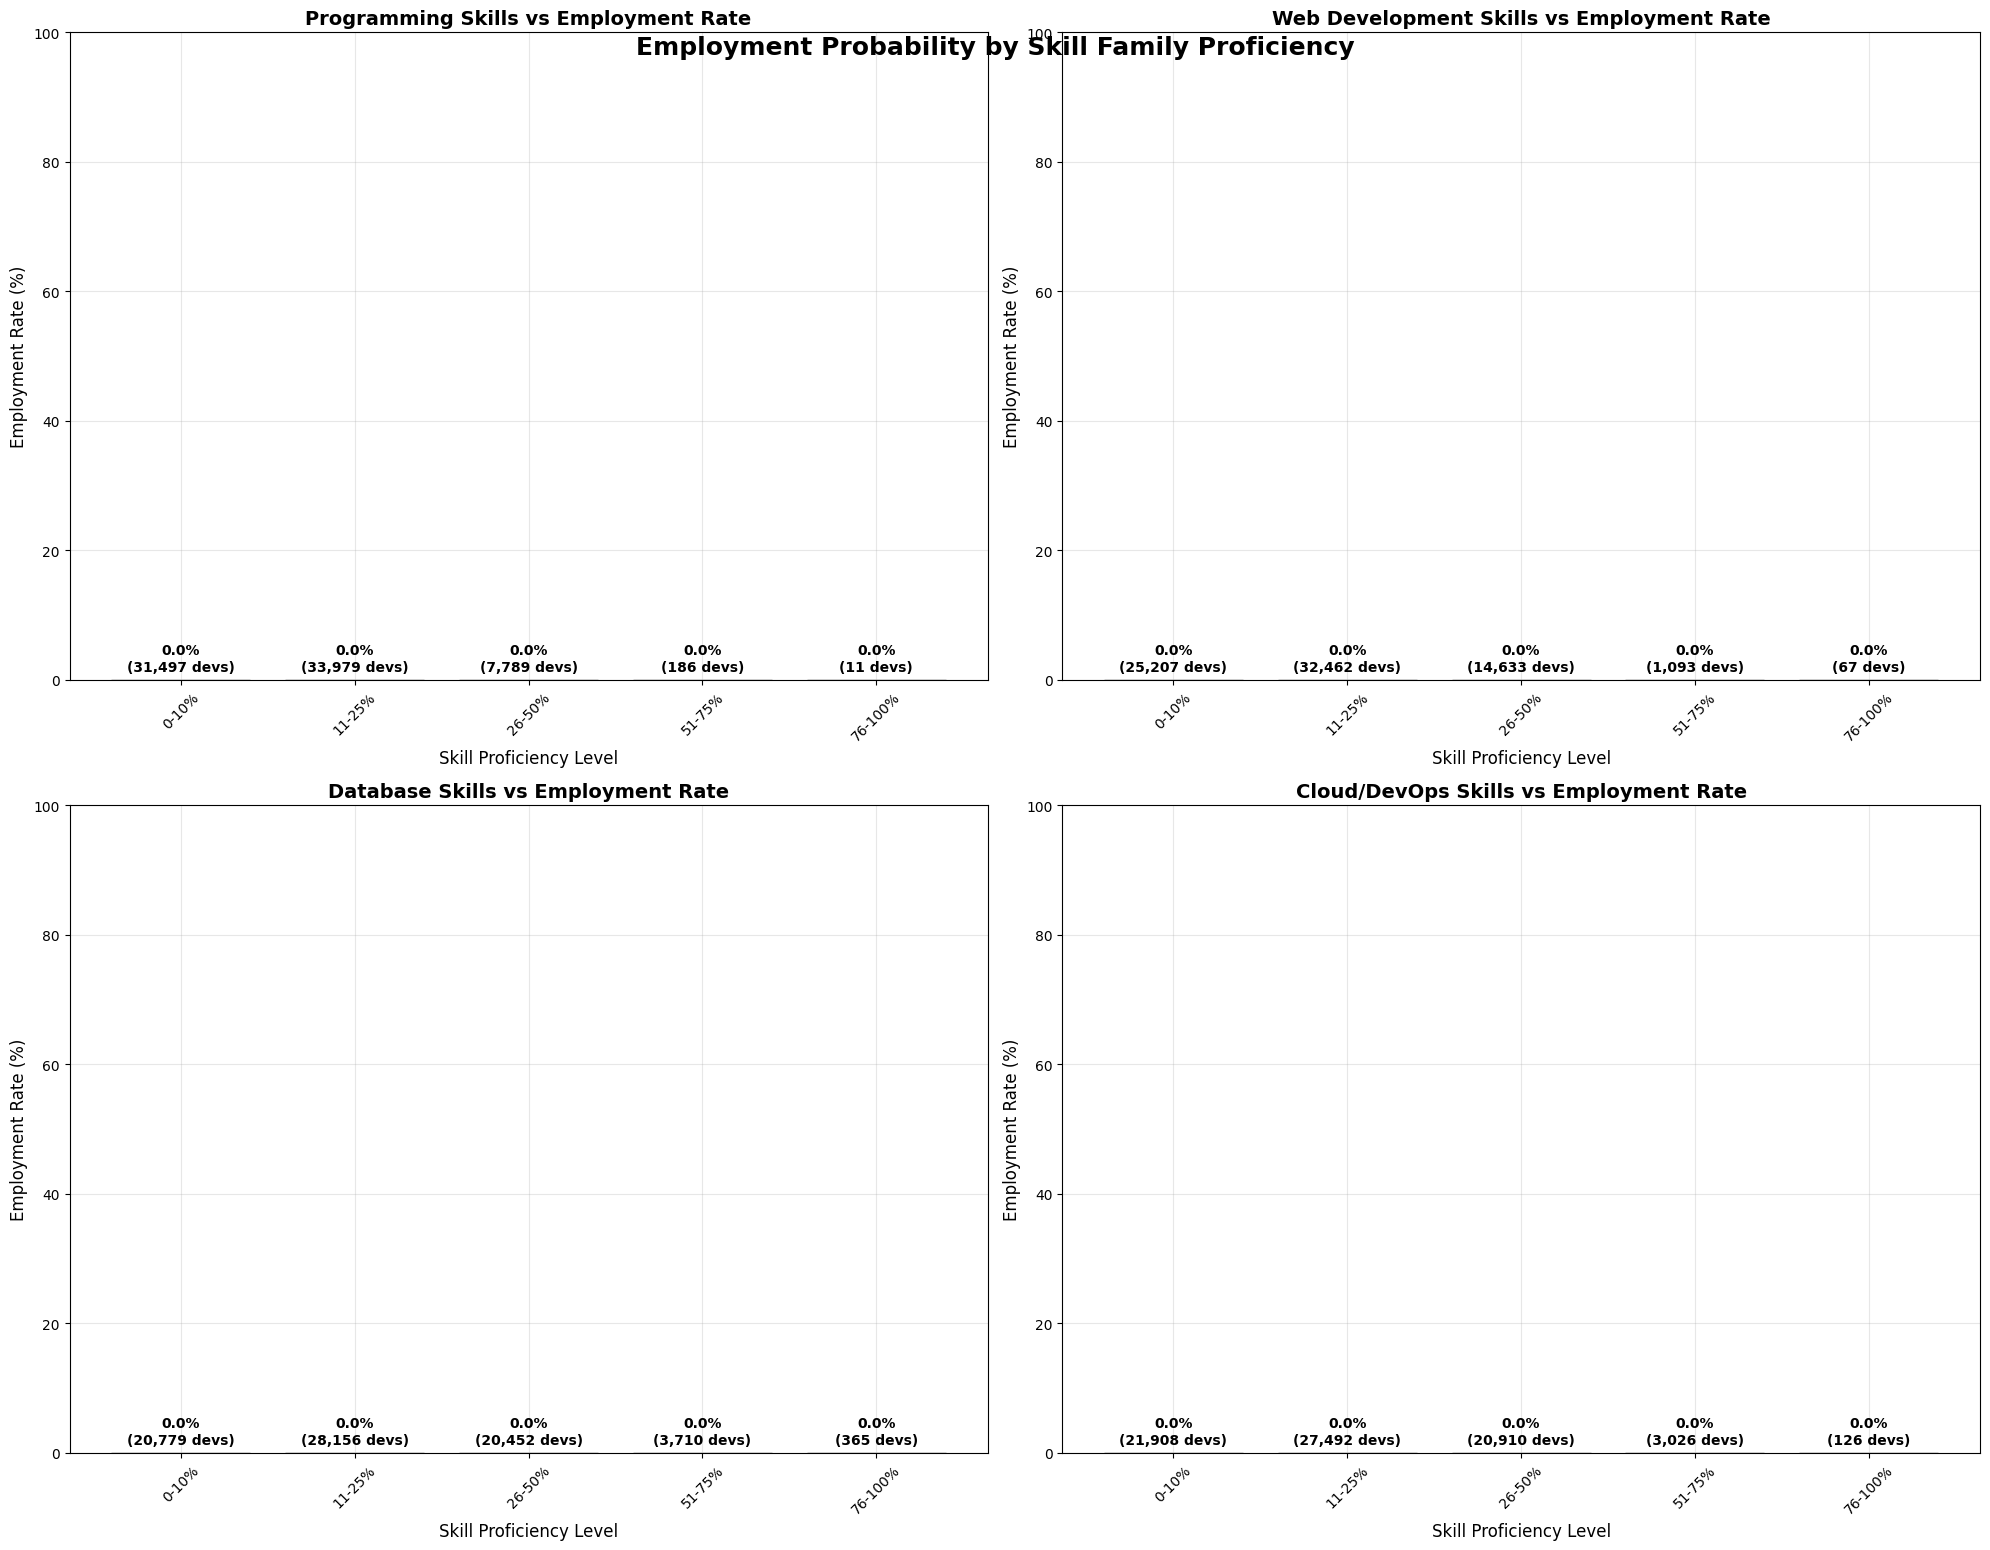

📊 Skill Family Employment Analysis Complete!


In [11]:
# Fix for the visualization cells - add this safety check at the start of each visualization:

# SAFETY CHECK - Only run if data is properly loaded
if df is None or 'Employed' not in df.columns:
    print("❌ Data not properly loaded. Please run the data loading cell first.")
    print("💡 Make sure you have:")
    print("   1. Preprocessed data file available")
    print("   2. All required columns (Employed, skill scores, etc.)")
else:
    print("✅ Data check passed - proceeding with visualizations...")

    # 1. SKILL FAMILY SCORES VS EMPLOYMENT (CORRECTED)
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    fig.suptitle('Employment Probability by Skill Family Proficiency', fontsize=18, fontweight='bold', y=0.95)

    skill_families = ['Programming_Score', 'Web_Score', 'Database_Score', 'CloudDevOps_Score']
    family_names = ['Programming', 'Web Development', 'Database', 'Cloud/DevOps']

    for idx, (skill, name) in enumerate(zip(skill_families, family_names)):
        if skill not in df.columns:
            print(f"⚠️ Column {skill} not found, skipping...")
            continue
            
        row, col = idx // 2, idx % 2
        
        # Create bins for skill scores
        bins = [0, 10, 25, 50, 75, 100]
        labels = ['0-10%', '11-25%', '26-50%', '51-75%', '76-100%']
        
        # Handle potential NaN values
        df[f'{skill}_bin'] = pd.cut(df[skill].fillna(0), bins=bins, labels=labels, include_lowest=True)
        
        # Calculate employment rate by skill level
        employment_by_skill = df.groupby(f'{skill}_bin')['Employed'].apply(
            lambda x: (x == 'Employed').mean() * 100
        ).reset_index()
        
        # Count of developers in each bin
        counts = df[f'{skill}_bin'].value_counts().sort_index()
        
        # Handle empty groups
        if employment_by_skill.empty:
            print(f"⚠️ No data for {skill}, skipping...")
            continue
        
        # Create bar plot
        bars = axes[row, col].bar(range(len(employment_by_skill)), 
                                  employment_by_skill['Employed'],
                                  color=['lightcoral', 'orange', 'gold', 'lightgreen', 'darkgreen'],
                                  alpha=0.8,
                                  edgecolor='black',
                                  linewidth=1)
        
        # Add count labels on bars
        for i, bar in enumerate(bars):
            height = bar.get_height()
            count = counts.iloc[i] if i < len(counts) else 0
            axes[row, col].text(bar.get_x() + bar.get_width()/2., height + 1,
                               f'{height:.1f}%\n({count:,} devs)',
                               ha='center', va='bottom', fontweight='bold', fontsize=10)
        
        axes[row, col].set_title(f'{name} Skills vs Employment Rate', fontweight='bold', fontsize=14)
        axes[row, col].set_xlabel('Skill Proficiency Level', fontsize=12)
        axes[row, col].set_ylabel('Employment Rate (%)', fontsize=12)
        axes[row, col].set_xticks(range(len(labels)))
        axes[row, col].set_xticklabels(labels, rotation=45)
        axes[row, col].grid(True, alpha=0.3)
        axes[row, col].set_ylim(0, 100)

    plt.tight_layout()
    plt.show()

    print("📊 Skill Family Employment Analysis Complete!")

🎨 FEATURE ENGINEERING VISUALIZATIONS


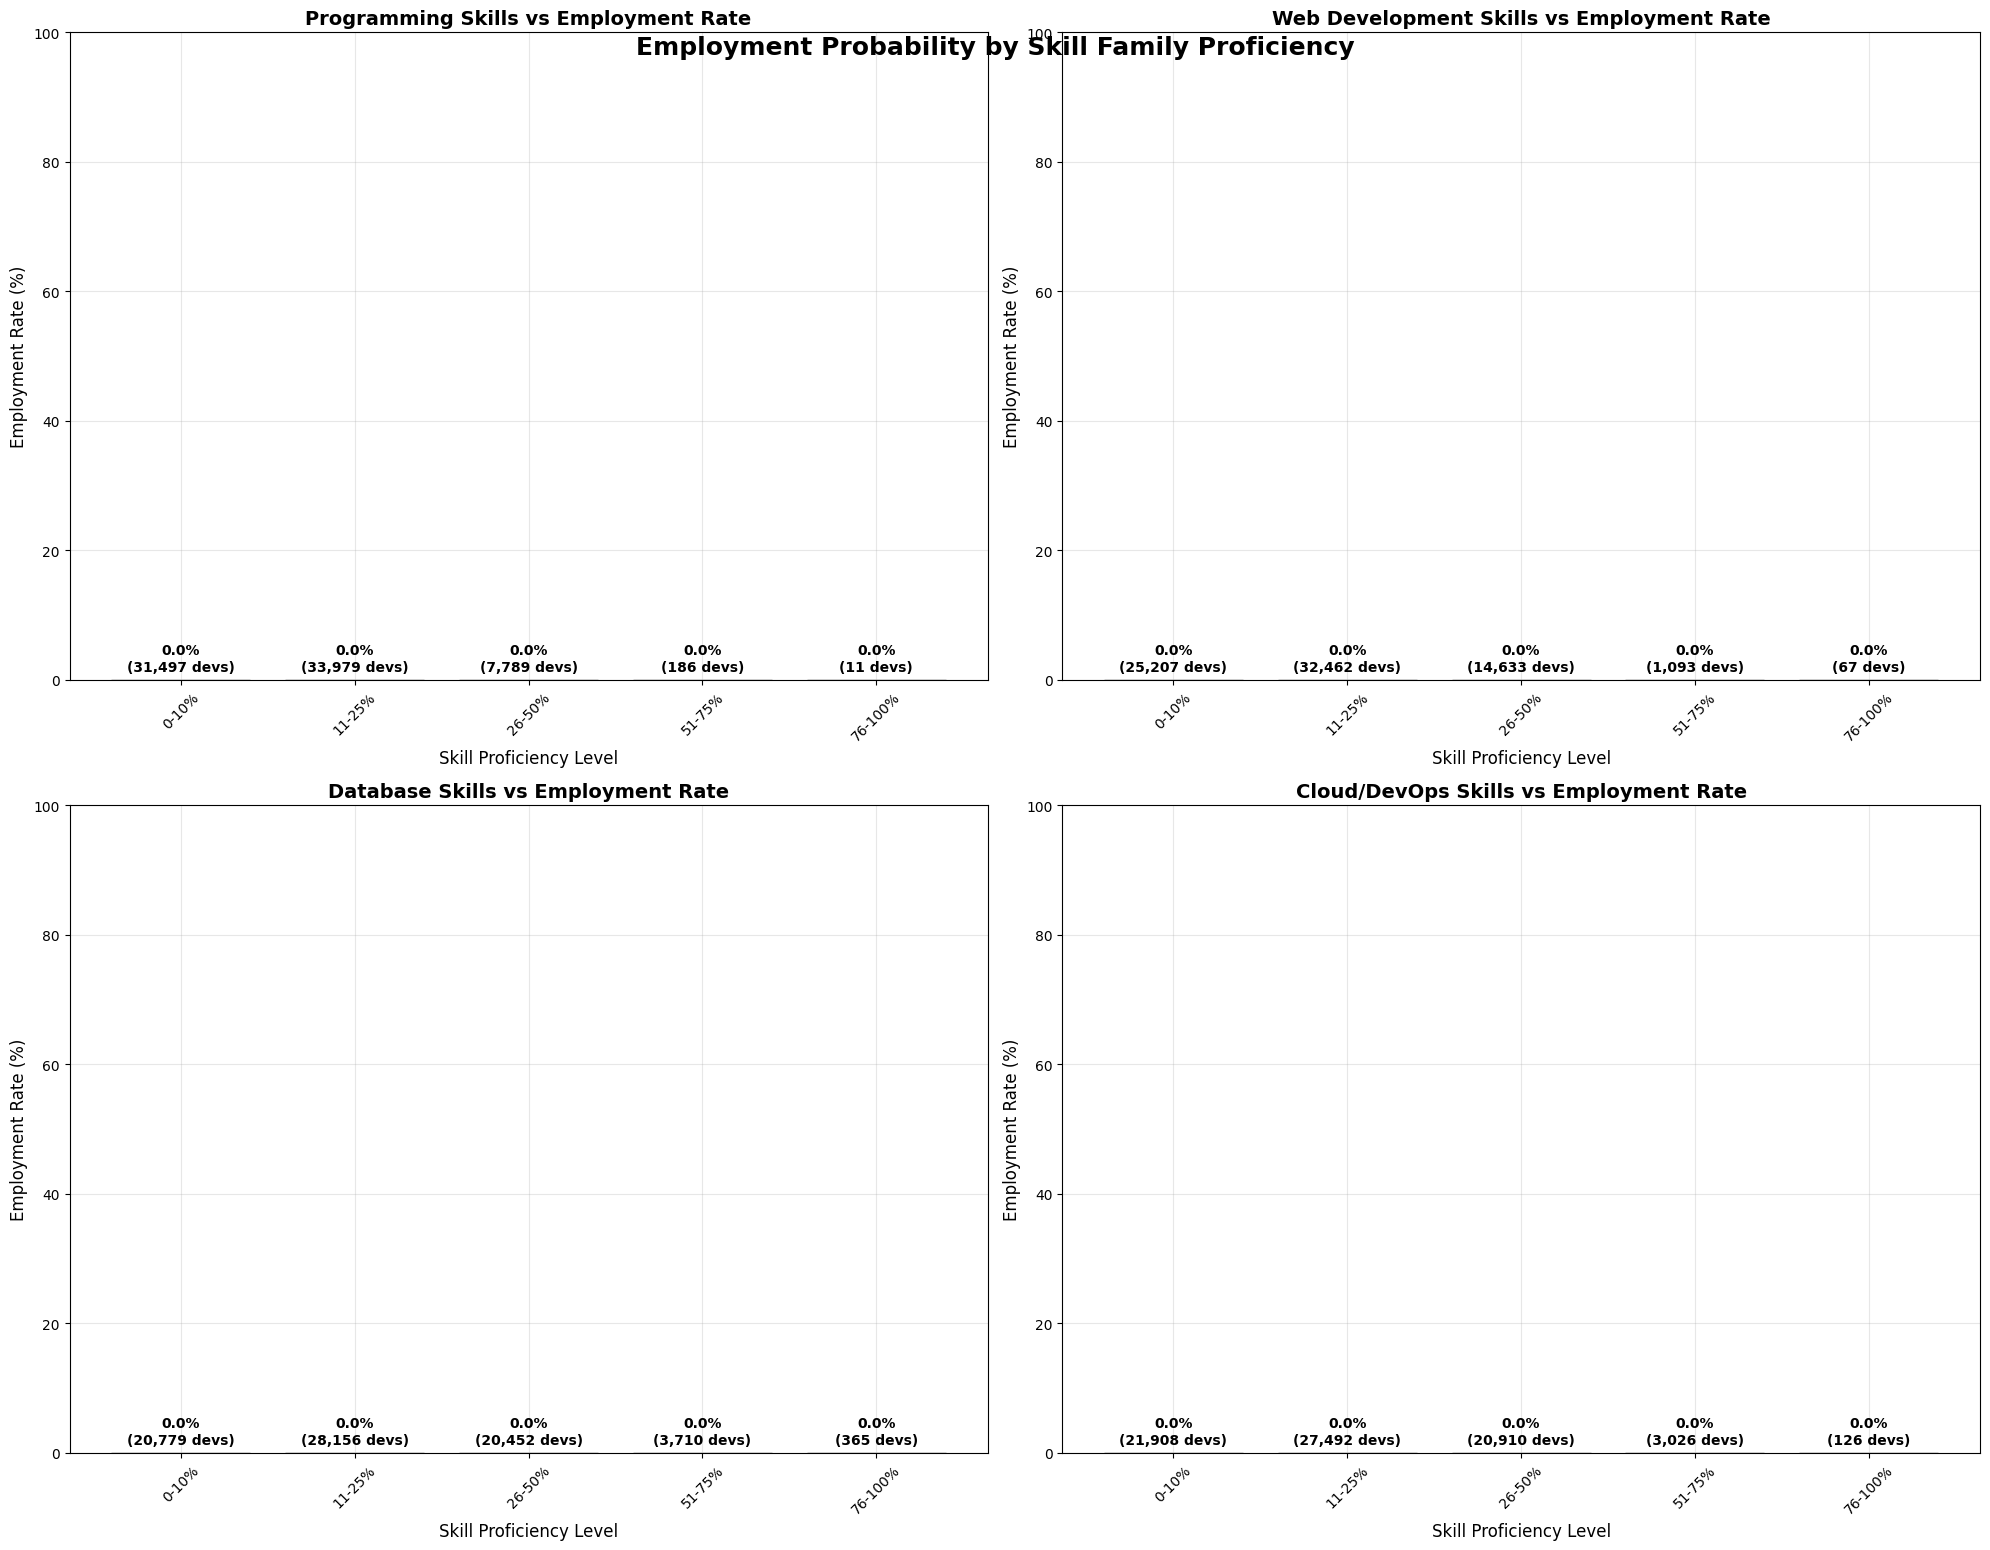

📊 Skill Family Employment Analysis Complete!


In [12]:
# =============================================================================
# FEATURE ENGINEERING VISUALIZATIONS FOR REPORT
# Employment vs Features Analysis
# =============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = [15, 10]

print("🎨 FEATURE ENGINEERING VISUALIZATIONS")
print("=" * 50)

# 1. SKILL FAMILY SCORES VS EMPLOYMENT
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
fig.suptitle('Employment Probability by Skill Family Proficiency', fontsize=18, fontweight='bold', y=0.95)

skill_families = ['Programming_Score', 'Web_Score', 'Database_Score', 'CloudDevOps_Score']
family_names = ['Programming', 'Web Development', 'Database', 'Cloud/DevOps']

for idx, (skill, name) in enumerate(zip(skill_families, family_names)):
    row, col = idx // 2, idx % 2
    
    # Create bins for skill scores
    bins = [0, 10, 25, 50, 75, 100]
    labels = ['0-10%', '11-25%', '26-50%', '51-75%', '76-100%']
    
    df['skill_bin'] = pd.cut(df[skill], bins=bins, labels=labels, include_lowest=True)
    
    # Calculate employment rate by skill level
    employment_by_skill = df.groupby('skill_bin')['Employed'].apply(
        lambda x: (x == 'Employed').mean() * 100
    ).reset_index()
    
    # Count of developers in each bin
    counts = df['skill_bin'].value_counts().sort_index()
    
    # Create bar plot
    bars = axes[row, col].bar(range(len(employment_by_skill)), 
                              employment_by_skill['Employed'],
                              color=['lightcoral', 'orange', 'gold', 'lightgreen', 'darkgreen'],
                              alpha=0.8,
                              edgecolor='black',
                              linewidth=1)
    
    # Add count labels on bars
    for i, (bar, count) in enumerate(zip(bars, counts.values)):
        height = bar.get_height()
        axes[row, col].text(bar.get_x() + bar.get_width()/2., height + 1,
                           f'{height:.1f}%\n({count:,} devs)',
                           ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    axes[row, col].set_title(f'{name} Skills vs Employment Rate', fontweight='bold', fontsize=14)
    axes[row, col].set_xlabel('Skill Proficiency Level', fontsize=12)
    axes[row, col].set_ylabel('Employment Rate (%)', fontsize=12)
    axes[row, col].set_xticks(range(len(labels)))
    axes[row, col].set_xticklabels(labels, rotation=45)
    axes[row, col].grid(True, alpha=0.3)
    axes[row, col].set_ylim(0, 100)

plt.tight_layout()
plt.show()

print("📊 Skill Family Employment Analysis Complete!")

⚠️ Column Age not found, skipping...
⚠️ Column Gender not found, skipping...
⚠️ Column EdLevel not found, skipping...
⚠️ Column MainBranch not found, skipping...
⚠️ Column MentalHealth not found, skipping...
⚠️ Column Accessibility not found, skipping...


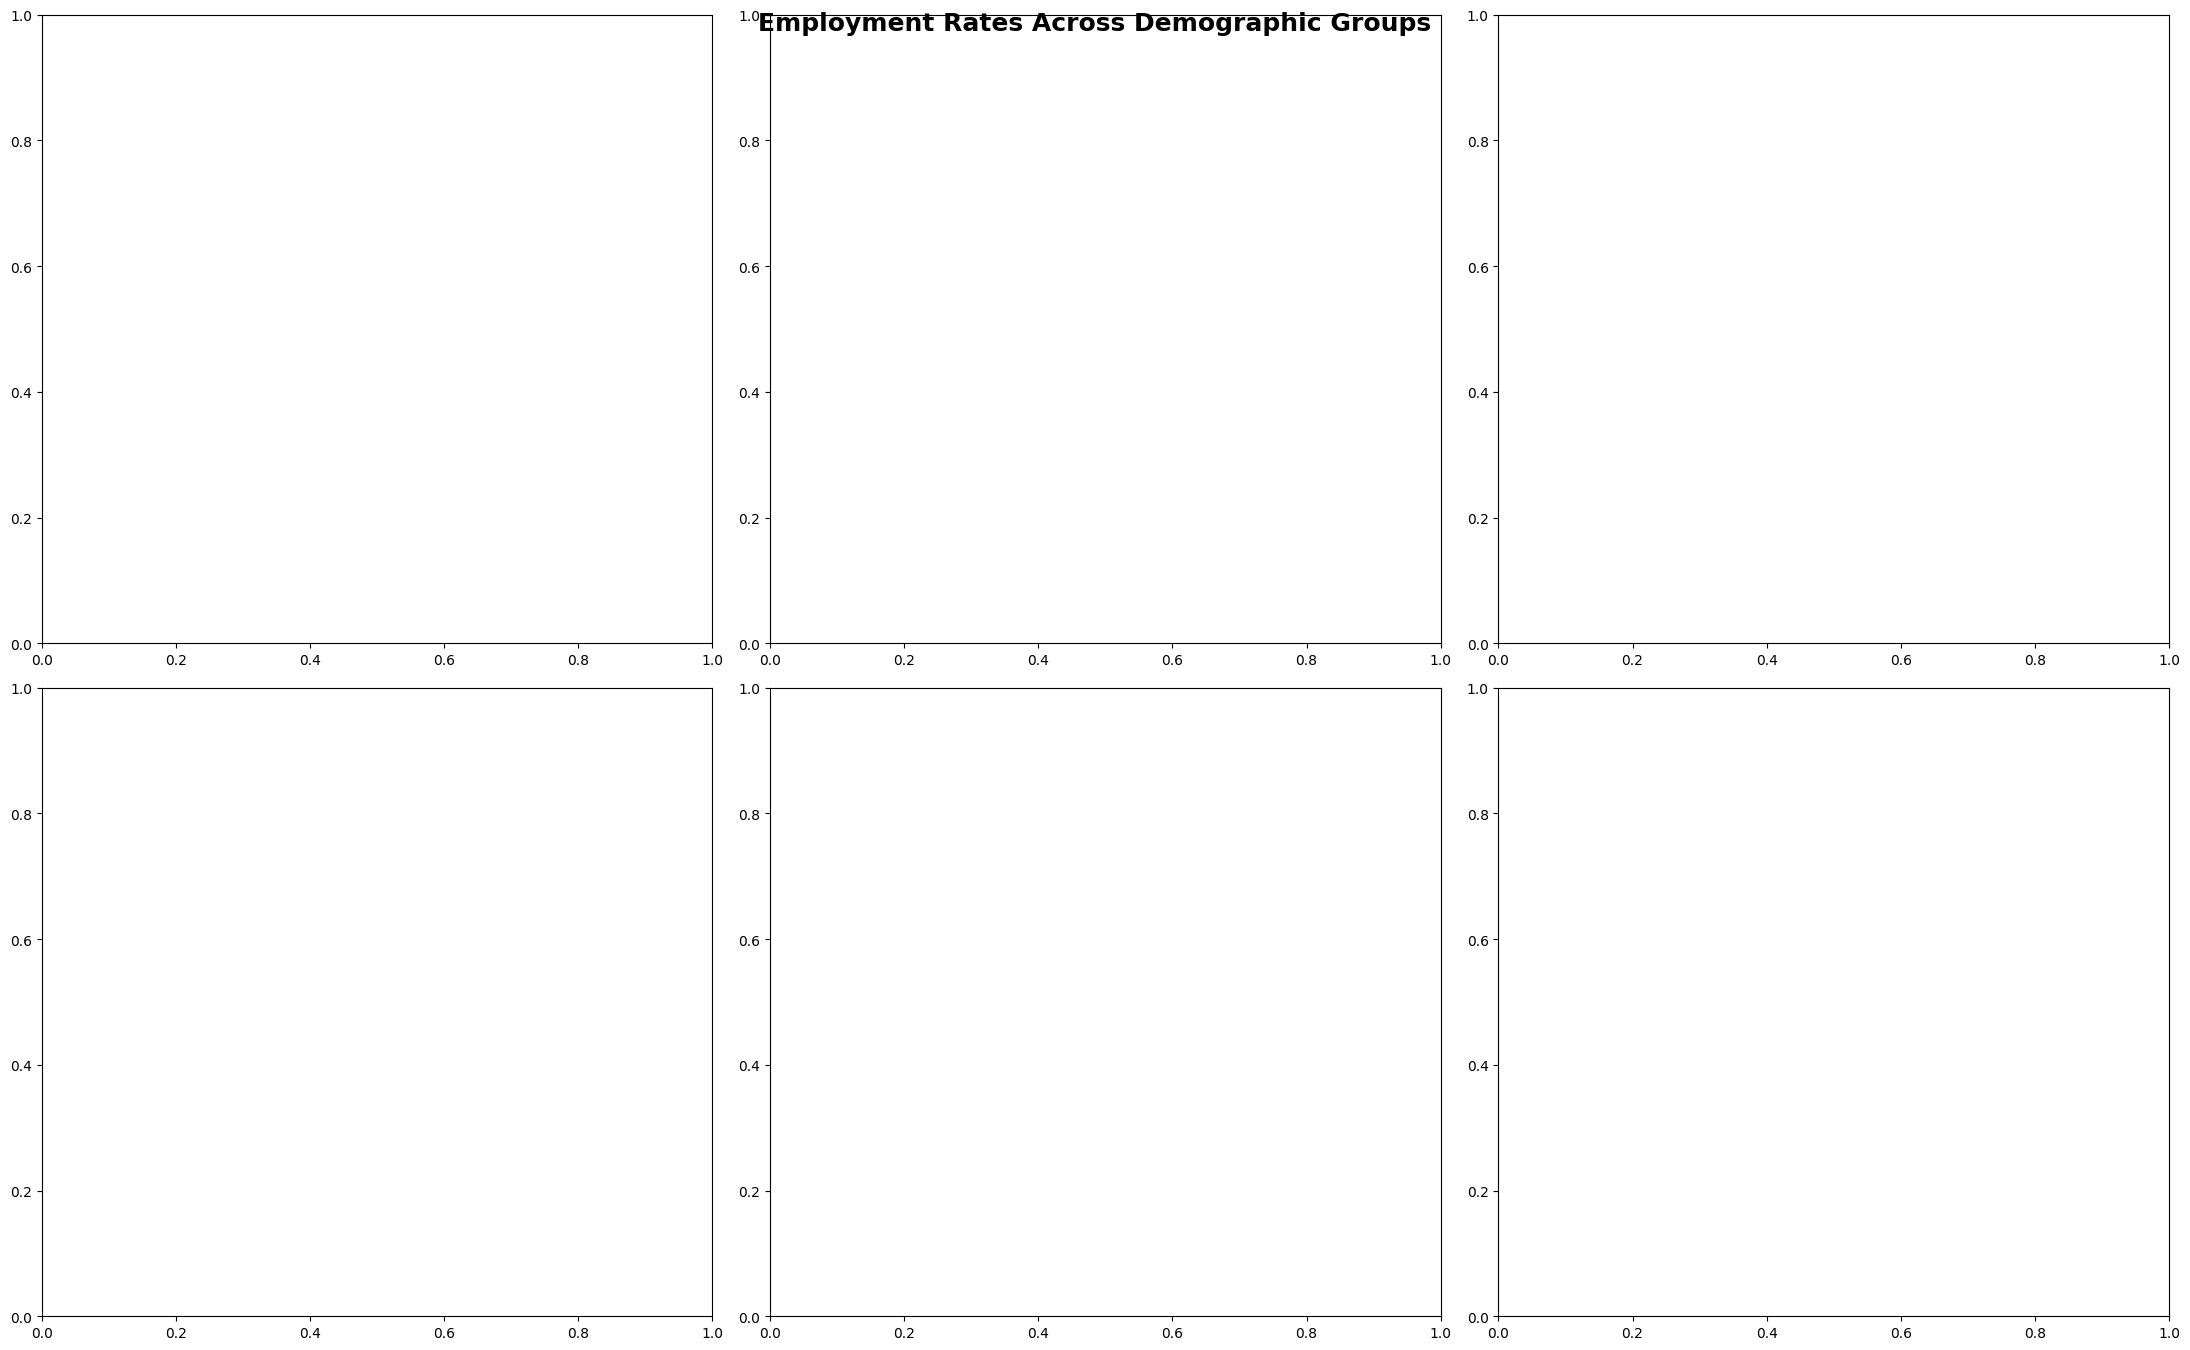

📊 Demographics Employment Analysis Complete!


In [13]:
# Fix for Demographics visualization:

if df is None or 'Employed' not in df.columns:
    print("❌ Data not available for demographics analysis")
else:
    # 2. DEMOGRAPHICS VS EMPLOYMENT (CORRECTED)
    fig, axes = plt.subplots(2, 3, figsize=(22, 14))
    fig.suptitle('Employment Rates Across Demographic Groups', fontsize=18, fontweight='bold', y=0.96)

    # Check and process each demographic variable
    demographic_vars = [
        ('Age', 'Age Group'),
        ('Gender', 'Gender'), 
        ('EdLevel', 'Education Level'),
        ('MainBranch', 'Developer Status'),
        ('MentalHealth', 'Mental Health'),
        ('Accessibility', 'Accessibility Needs')
    ]
    
    colors_list = [
        ['skyblue', 'lightcoral'],
        ['lightblue', 'pink', 'lightgreen', 'gray'],
        ['lightcoral', 'orange', 'gold', 'lightgreen', 'darkgreen'],
        ['green', 'red'],
        ['lightgreen', 'lightcoral'],
        ['lightblue', 'orange']
    ]

    for idx, (col_name, title) in enumerate(demographic_vars):
        if col_name not in df.columns:
            print(f"⚠️ Column {col_name} not found, skipping...")
            continue
            
        row, col = idx // 3, idx % 3
        
        try:
            # Calculate employment rates
            var_employment = df.groupby(col_name)['Employed'].apply(
                lambda x: (x == 'Employed').mean() * 100
            ).reset_index()
            var_counts = df[col_name].value_counts()

            # Create bar plot
            bars = axes[row, col].bar(range(len(var_employment)), var_employment['Employed'],
                                     color=colors_list[idx][:len(var_employment)], 
                                     alpha=0.8, edgecolor='black')
            
            axes[row, col].set_title(f'Employment Rate by {title}', fontweight='bold')
            axes[row, col].set_xlabel(title)
            axes[row, col].set_ylabel('Employment Rate (%)')
            axes[row, col].set_xticks(range(len(var_employment)))
            axes[row, col].set_xticklabels(var_employment[col_name], rotation=45 if idx in [1, 2] else 0)

            # Add labels
            for i, (bar, category) in enumerate(zip(bars, var_employment[col_name])):
                height = bar.get_height()
                count = var_counts.get(category, 0)
                axes[row, col].text(bar.get_x() + bar.get_width()/2., height + 1,
                                   f'{height:.1f}%\n({count:,})',
                                   ha='center', va='bottom', fontweight='bold')
                                   
        except Exception as e:
            print(f"⚠️ Error processing {col_name}: {str(e)}")
            axes[row, col].text(0.5, 0.5, f'Data not available\nfor {title}', 
                               ha='center', va='center', transform=axes[row, col].transAxes)

    plt.tight_layout()
    plt.show()

    print("📊 Demographics Employment Analysis Complete!")

NameError: name 'df' is not defined

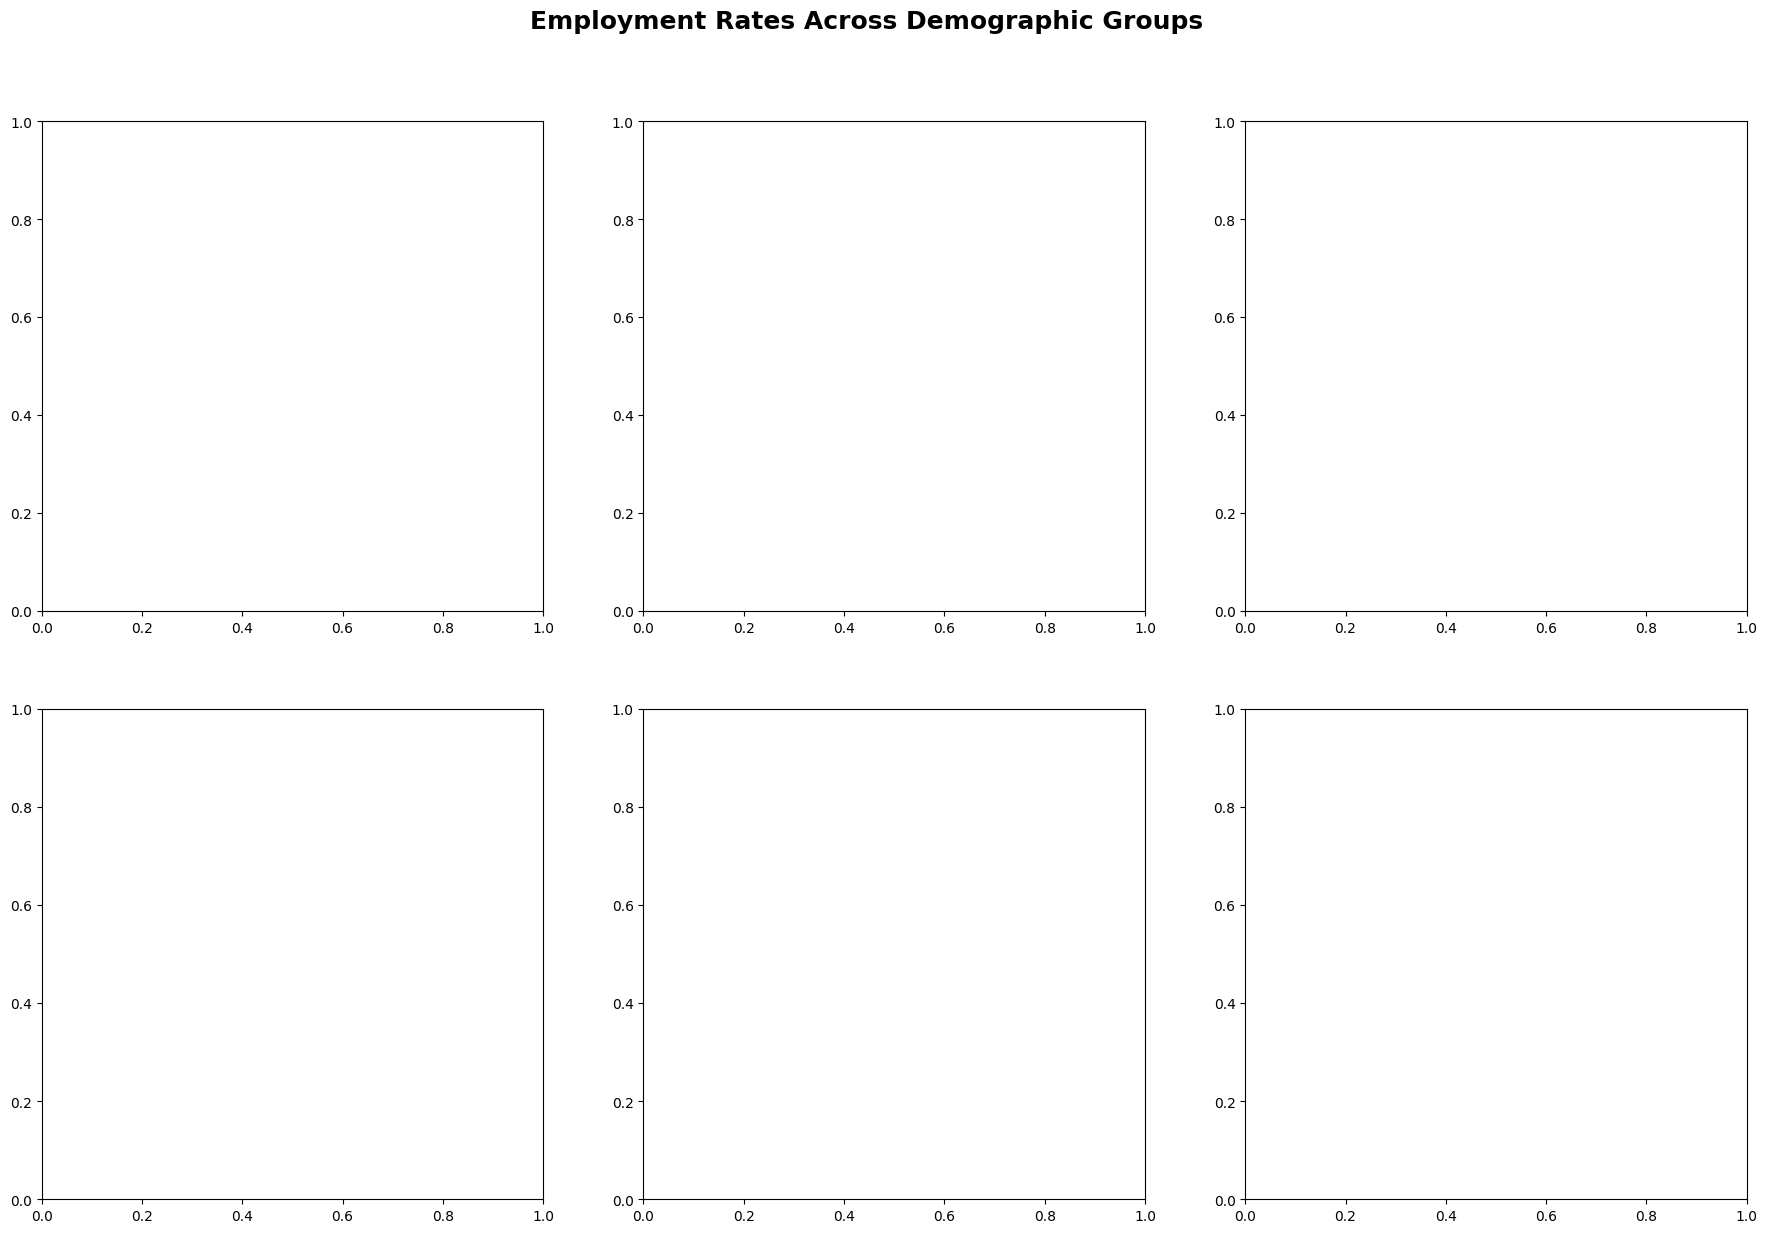

In [4]:
# 2. DEMOGRAPHICS VS EMPLOYMENT
fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.suptitle('Employment Rates Across Demographic Groups', fontsize=18, fontweight='bold', y=0.96)

# Age Groups
age_employment = df.groupby('Age')['Employed'].apply(
    lambda x: (x == 'Employed').mean() * 100
).reset_index()
age_counts = df['Age'].value_counts()

bars1 = axes[0, 0].bar(range(len(age_employment)), age_employment['Employed'],
                       color=['skyblue', 'lightcoral'], alpha=0.8, edgecolor='black')
axes[0, 0].set_title('Employment Rate by Age Group', fontweight='bold')
axes[0, 0].set_xlabel('Age Group')
axes[0, 0].set_ylabel('Employment Rate (%)')
axes[0, 0].set_xticks(range(len(age_employment)))
axes[0, 0].set_xticklabels(age_employment['Age'])

# Add labels
for i, (bar, age) in enumerate(zip(bars1, age_employment['Age'])):
    height = bar.get_height()
    count = age_counts[age]
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., height + 1,
                   f'{height:.1f}%\n({count:,})',
                   ha='center', va='bottom', fontweight='bold')

# Gender
gender_employment = df.groupby('Gender')['Employed'].apply(
    lambda x: (x == 'Employed').mean() * 100
).reset_index()
gender_counts = df['Gender'].value_counts()

bars2 = axes[0, 1].bar(range(len(gender_employment)), gender_employment['Employed'],
                       color=['lightblue', 'pink', 'lightgreen', 'gray'], alpha=0.8, edgecolor='black')
axes[0, 1].set_title('Employment Rate by Gender', fontweight='bold')
axes[0, 1].set_xlabel('Gender')
axes[0, 1].set_ylabel('Employment Rate (%)')
axes[0, 1].set_xticks(range(len(gender_employment)))
axes[0, 1].set_xticklabels(gender_employment['Gender'], rotation=45)

for i, (bar, gender) in enumerate(zip(bars2, gender_employment['Gender'])):
    height = bar.get_height()
    count = gender_counts[gender]
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., height + 1,
                   f'{height:.1f}%\n({count:,})',
                   ha='center', va='bottom', fontweight='bold')

# Education Level
edu_employment = df.groupby('EdLevel')['Employed'].apply(
    lambda x: (x == 'Employed').mean() * 100
).reset_index()
edu_counts = df['EdLevel'].value_counts()

bars3 = axes[0, 2].bar(range(len(edu_employment)), edu_employment['Employed'],
                       color=['lightcoral', 'orange', 'gold', 'lightgreen', 'darkgreen'], 
                       alpha=0.8, edgecolor='black')
axes[0, 2].set_title('Employment Rate by Education Level', fontweight='bold')
axes[0, 2].set_xlabel('Education Level')
axes[0, 2].set_ylabel('Employment Rate (%)')
axes[0, 2].set_xticks(range(len(edu_employment)))
axes[0, 2].set_xticklabels(edu_employment['EdLevel'], rotation=45)

for i, (bar, edu) in enumerate(zip(bars3, edu_employment['EdLevel'])):
    height = bar.get_height()
    count = edu_counts[edu]
    axes[0, 2].text(bar.get_x() + bar.get_width()/2., height + 1,
                   f'{height:.1f}%\n({count:,})',
                   ha='center', va='bottom', fontweight='bold')

# Developer Status
dev_employment = df.groupby('MainBranch')['Employed'].apply(
    lambda x: (x == 'Employed').mean() * 100
).reset_index()
dev_counts = df['MainBranch'].value_counts()

bars4 = axes[1, 0].bar(range(len(dev_employment)), dev_employment['Employed'],
                       color=['green', 'red'], alpha=0.8, edgecolor='black')
axes[1, 0].set_title('Employment Rate by Developer Status', fontweight='bold')
axes[1, 0].set_xlabel('Developer Status')
axes[1, 0].set_ylabel('Employment Rate (%)')
axes[1, 0].set_xticks(range(len(dev_employment)))
axes[1, 0].set_xticklabels(dev_employment['MainBranch'])

for i, (bar, dev) in enumerate(zip(bars4, dev_employment['MainBranch'])):
    height = bar.get_height()
    count = dev_counts[dev]
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height + 1,
                   f'{height:.1f}%\n({count:,})',
                   ha='center', va='bottom', fontweight='bold')

# Mental Health
mental_employment = df.groupby('MentalHealth')['Employed'].apply(
    lambda x: (x == 'Employed').mean() * 100
).reset_index()
mental_counts = df['MentalHealth'].value_counts()

bars5 = axes[1, 1].bar(range(len(mental_employment)), mental_employment['Employed'],
                       color=['lightgreen', 'lightcoral'], alpha=0.8, edgecolor='black')
axes[1, 1].set_title('Employment Rate by Mental Health Status', fontweight='bold')
axes[1, 1].set_xlabel('Mental Health Concerns')
axes[1, 1].set_ylabel('Employment Rate (%)')
axes[1, 1].set_xticks(range(len(mental_employment)))
axes[1, 1].set_xticklabels(mental_employment['MentalHealth'])

for i, (bar, mental) in enumerate(zip(bars5, mental_employment['MentalHealth'])):
    height = bar.get_height()
    count = mental_counts[mental]
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 1,
                   f'{height:.1f}%\n({count:,})',
                   ha='center', va='bottom', fontweight='bold')

# Accessibility
access_employment = df.groupby('Accessibility')['Employed'].apply(
    lambda x: (x == 'Employed').mean() * 100
).reset_index()
access_counts = df['Accessibility'].value_counts()

bars6 = axes[1, 2].bar(range(len(access_employment)), access_employment['Employed'],
                       color=['lightblue', 'orange'], alpha=0.8, edgecolor='black')
axes[1, 2].set_title('Employment Rate by Accessibility Needs', fontweight='bold')
axes[1, 2].set_xlabel('Accessibility Needs')
axes[1, 2].set_ylabel('Employment Rate (%)')
axes[1, 2].set_xticks(range(len(access_employment)))
axes[1, 2].set_xticklabels(access_employment['Accessibility'])

for i, (bar, access) in enumerate(zip(bars6, access_employment['Accessibility'])):
    height = bar.get_height()
    count = access_counts[access]
    axes[1, 2].text(bar.get_x() + bar.get_width()/2., height + 1,
                   f'{height:.1f}%\n({count:,})',
                   ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("📊 Demographics Employment Analysis Complete!")

NameError: name 'df' is not defined

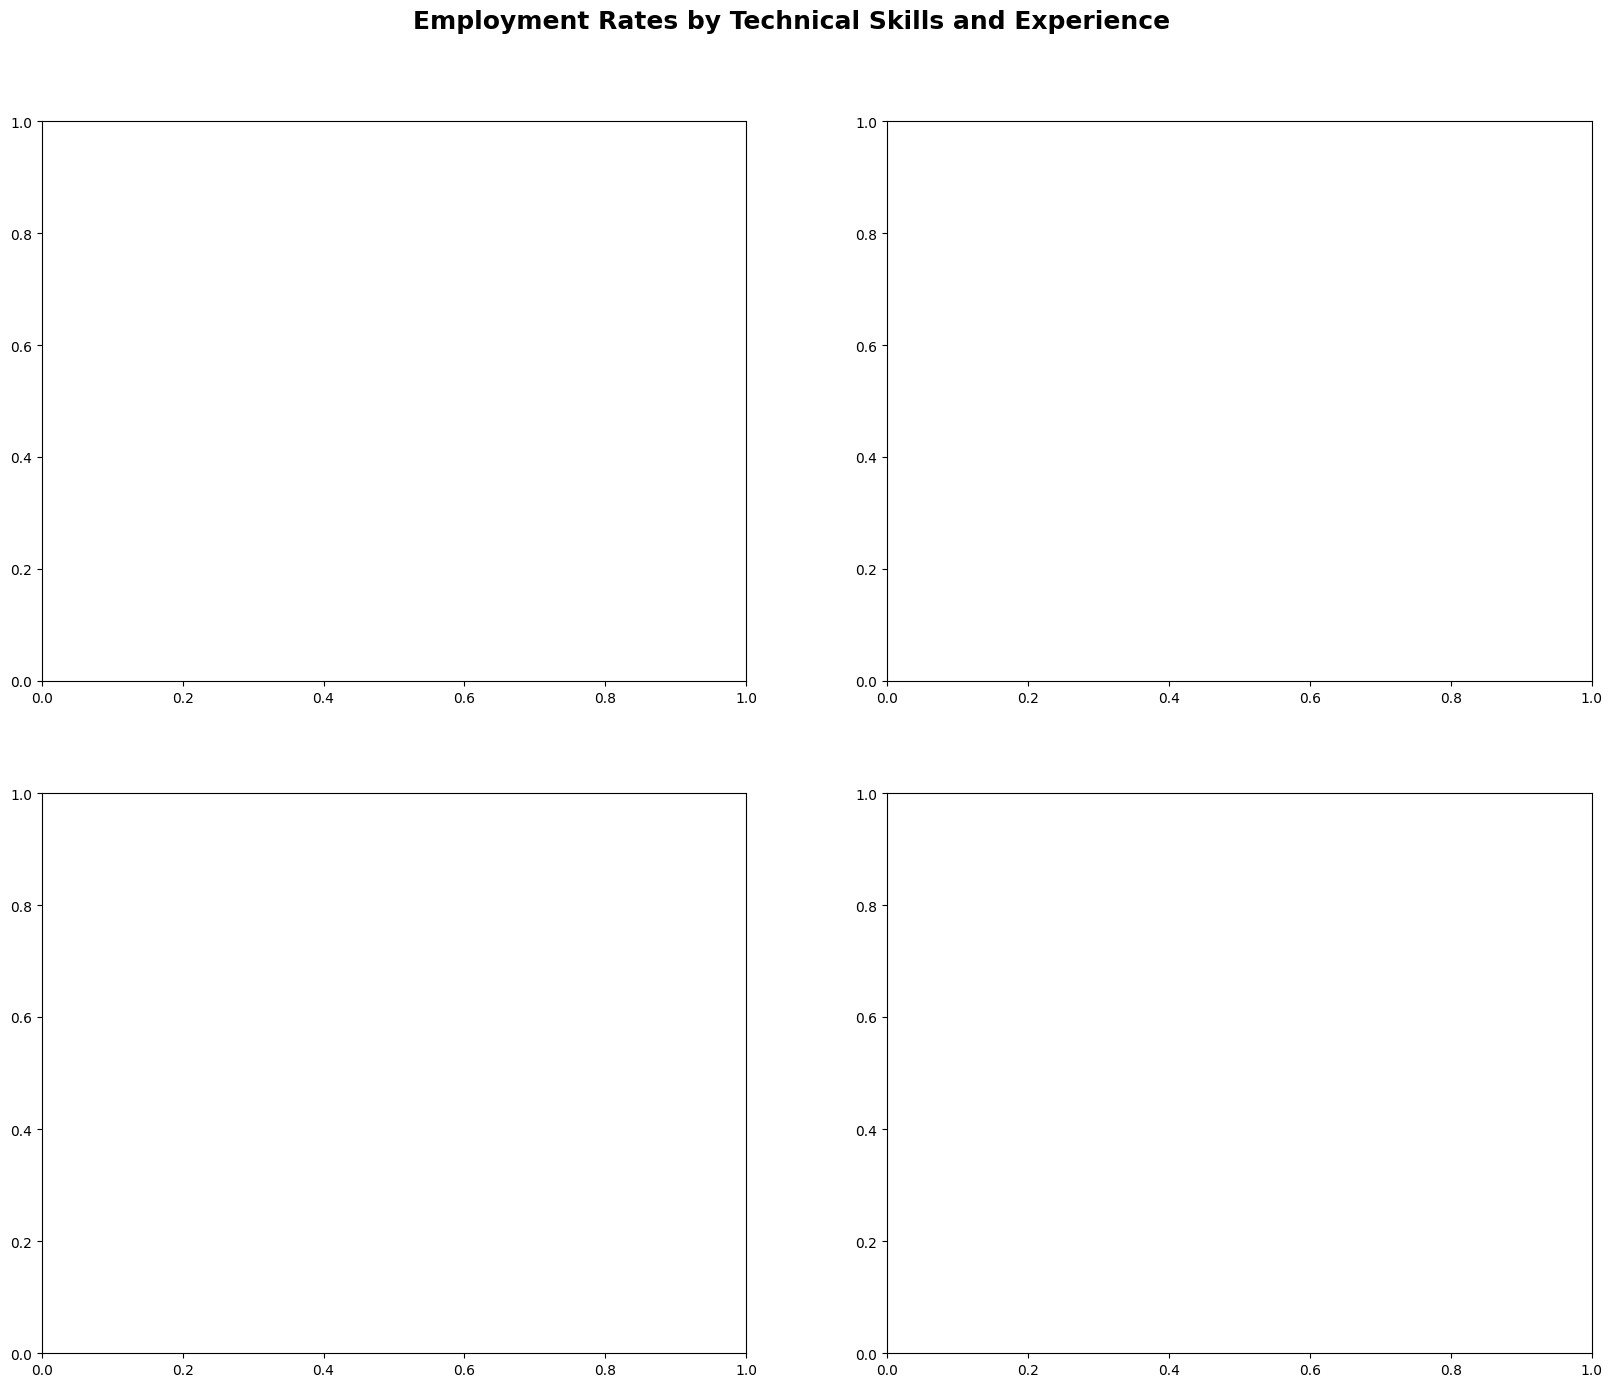

In [5]:
# 3. COMPUTER SKILLS AND EXPERIENCE VS EMPLOYMENT
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
fig.suptitle('Employment Rates by Technical Skills and Experience', fontsize=18, fontweight='bold', y=0.95)

# Computer Skills Distribution
bins = [0, 5, 10, 15, 20, 30, 50]
labels = ['0-5', '6-10', '11-15', '16-20', '21-30', '31+']
df['skill_range'] = pd.cut(df['ComputerSkills'], bins=bins, labels=labels, include_lowest=True)

skill_employment = df.groupby('skill_range')['Employed'].apply(
    lambda x: (x == 'Employed').mean() * 100
).reset_index()
skill_counts = df['skill_range'].value_counts().sort_index()

bars1 = axes[0, 0].bar(range(len(skill_employment)), skill_employment['Employed'],
                       color=['red', 'orange', 'gold', 'lightgreen', 'green', 'darkgreen'],
                       alpha=0.8, edgecolor='black')
axes[0, 0].set_title('Employment Rate by Number of Computer Skills', fontweight='bold')
axes[0, 0].set_xlabel('Number of Computer Skills')
axes[0, 0].set_ylabel('Employment Rate (%)')
axes[0, 0].set_xticks(range(len(labels)))
axes[0, 0].set_xticklabels(labels)

for i, bar in enumerate(bars1):
    height = bar.get_height()
    count = skill_counts.iloc[i] if i < len(skill_counts) else 0
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., height + 1,
                   f'{height:.1f}%\n({count:,})',
                   ha='center', va='bottom', fontweight='bold')

# Professional Experience (YearsCodePro)
exp_bins = [0, 1, 3, 5, 10, 20, 50]
exp_labels = ['0-1', '2-3', '4-5', '6-10', '11-20', '21+']
df['exp_range'] = pd.cut(df['YearsCodePro'], bins=exp_bins, labels=exp_labels, include_lowest=True)

exp_employment = df.groupby('exp_range')['Employed'].apply(
    lambda x: (x == 'Employed').mean() * 100
).reset_index()
exp_counts = df['exp_range'].value_counts().sort_index()

bars2 = axes[0, 1].bar(range(len(exp_employment)), exp_employment['Employed'],
                       color=['lightcoral', 'orange', 'gold', 'lightgreen', 'green', 'darkgreen'],
                       alpha=0.8, edgecolor='black')
axes[0, 1].set_title('Employment Rate by Years of Professional Experience', fontweight='bold')
axes[0, 1].set_xlabel('Years of Professional Experience')
axes[0, 1].set_ylabel('Employment Rate (%)')
axes[0, 1].set_xticks(range(len(exp_labels)))
axes[0, 1].set_xticklabels(exp_labels)

for i, bar in enumerate(bars2):
    height = bar.get_height()
    count = exp_counts.iloc[i] if i < len(exp_counts) else 0
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., height + 1,
                   f'{height:.1f}%\n({count:,})',
                   ha='center', va='bottom', fontweight='bold')

# Full Stack vs Specialization
fullstack_employment = df.groupby('Is_FullStack')['Employed'].apply(
    lambda x: (x == 'Employed').mean() * 100
).reset_index()
fullstack_employment['Category'] = fullstack_employment['Is_FullStack'].map({0: 'Specialized', 1: 'Full-Stack'})
fullstack_counts = df['Is_FullStack'].value_counts()

bars3 = axes[1, 0].bar(range(len(fullstack_employment)), fullstack_employment['Employed'],
                       color=['lightblue', 'darkblue'], alpha=0.8, edgecolor='black')
axes[1, 0].set_title('Employment Rate: Full-Stack vs Specialized Developers', fontweight='bold')
axes[1, 0].set_xlabel('Developer Type')
axes[1, 0].set_ylabel('Employment Rate (%)')
axes[1, 0].set_xticks(range(len(fullstack_employment)))
axes[1, 0].set_xticklabels(fullstack_employment['Category'])

for i, (bar, category) in enumerate(zip(bars3, fullstack_employment['Is_FullStack'])):
    height = bar.get_height()
    count = fullstack_counts[category]
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height + 1,
                   f'{height:.1f}%\n({count:,})',
                   ha='center', va='bottom', fontweight='bold')

# Skill Breadth Analysis
breadth_employment = df.groupby('Skill_Breadth')['Employed'].apply(
    lambda x: (x == 'Employed').mean() * 100
).reset_index()
breadth_counts = df['Skill_Breadth'].value_counts().sort_index()

bars4 = axes[1, 1].bar(range(len(breadth_employment)), breadth_employment['Employed'],
                       color=['red', 'orange', 'gold', 'lightgreen', 'darkgreen'],
                       alpha=0.8, edgecolor='black')
axes[1, 1].set_title('Employment Rate by Skill Breadth', fontweight='bold')
axes[1, 1].set_xlabel('Number of Skill Families (0-4)')
axes[1, 1].set_ylabel('Employment Rate (%)')
axes[1, 1].set_xticks(range(len(breadth_employment)))
axes[1, 1].set_xticklabels(breadth_employment['Skill_Breadth'])

for i, bar in enumerate(bars4):
    height = bar.get_height()
    breadth = breadth_employment.iloc[i]['Skill_Breadth']
    count = breadth_counts.get(breadth, 0)
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 1,
                   f'{height:.1f}%\n({count:,})',
                   ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("📊 Technical Skills & Experience Analysis Complete!")

In [6]:
# 4. FEATURE CORRELATION WITH EMPLOYMENT TARGET
employment_numeric = (df['Employed'] == 'Employed').astype(int)

# Calculate correlations with employment
correlations = {}
feature_list = [
    'Programming_Score', 'Web_Score', 'Database_Score', 'CloudDevOps_Score',
    'Has_Programming', 'Has_Web', 'Has_Database', 'Has_CloudDevOps',
    'Skill_Breadth', 'Is_FullStack', 'ComputerSkills',
    'EducationLevel_Numeric', 'IsYoung', 'IsDeveloper',
    'HasMentalHealthConcerns', 'HasAccessibilityNeeds',
    'Gender_Man', 'Gender_Woman', 'Gender_NonBinary',
    'HasProfessionalExperience', 'HasSalaryInfo'
]

for feature in feature_list:
    if feature in df.columns:
        correlations[feature] = employment_numeric.corr(df[feature])

# Sort by absolute correlation value
sorted_correlations = dict(sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True))

# Create visualization
plt.figure(figsize=(14, 10))

features = list(sorted_correlations.keys())
values = list(sorted_correlations.values())

# Color bars based on positive/negative correlation
colors = ['darkgreen' if v > 0 else 'darkred' for v in values]

bars = plt.barh(range(len(features)), values, color=colors, alpha=0.7, edgecolor='black')

plt.yticks(range(len(features)), features)
plt.xlabel('Correlation with Employment', fontsize=12, fontweight='bold')
plt.title('Feature Correlation with Employment Status\n(Green = Positive, Red = Negative)', 
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')

# Add correlation values as labels
for i, (bar, value) in enumerate(zip(bars, values)):
    width = bar.get_width()
    plt.text(width + (0.005 if width > 0 else -0.005), bar.get_y() + bar.get_height()/2,
             f'{value:.3f}', ha='left' if width > 0 else 'right', va='center', fontweight='bold')

plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print("📊 Feature Correlation Analysis Complete!")
print(f"🎯 Top 5 Positive Correlations:")
positive_corr = {k: v for k, v in sorted_correlations.items() if v > 0}
for i, (feature, corr) in enumerate(list(positive_corr.items())[:5], 1):
    print(f"   {i}. {feature}: {corr:.3f}")

print(f"\n🎯 Top 5 Negative Correlations:")
negative_corr = {k: v for k, v in sorted_correlations.items() if v < 0}
for i, (feature, corr) in enumerate(list(negative_corr.items())[:5], 1):
    print(f"   {i}. {feature}: {corr:.3f}")

NameError: name 'df' is not defined

In [7]:
# 5. INDIVIDUAL TECHNOLOGY ANALYSIS
# Parse all technologies and analyze employment rates
tech_employment = {}
tech_counts = {}

for idx, row in df.iterrows():
    employed = row['Employed'] == 'Employed'
    tech_list = row['Technologies_List']
    
    for tech in tech_list:
        if tech not in tech_employment:
            tech_employment[tech] = []
            tech_counts[tech] = 0
        
        tech_employment[tech].append(employed)
        tech_counts[tech] += 1

# Calculate employment rates for technologies with at least 100 users
tech_stats = {}
for tech, employed_list in tech_employment.items():
    if len(employed_list) >= 100:  # Only technologies used by 100+ developers
        employment_rate = (sum(employed_list) / len(employed_list)) * 100
        tech_stats[tech] = {
            'employment_rate': employment_rate,
            'user_count': len(employed_list)
        }

# Sort by employment rate
sorted_tech_stats = dict(sorted(tech_stats.items(), key=lambda x: x[1]['employment_rate'], reverse=True))

# Get top and bottom technologies
top_techs = dict(list(sorted_tech_stats.items())[:15])
bottom_techs = dict(list(sorted_tech_stats.items())[-15:])

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 10))

# Top performing technologies
tech_names = list(top_techs.keys())
employment_rates = [top_techs[tech]['employment_rate'] for tech in tech_names]
user_counts = [top_techs[tech]['user_count'] for tech in tech_names]

bars1 = ax1.barh(range(len(tech_names)), employment_rates, color='darkgreen', alpha=0.7, edgecolor='black')
ax1.set_yticks(range(len(tech_names)))
ax1.set_yticklabels(tech_names)
ax1.set_xlabel('Employment Rate (%)', fontweight='bold')
ax1.set_title('Top 15 Technologies by Employment Success Rate\n(Min 100 users)', fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

for i, (bar, rate, count) in enumerate(zip(bars1, employment_rates, user_counts)):
    ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{rate:.1f}% ({count:,})', ha='left', va='center', fontweight='bold')

# Bottom performing technologies
tech_names_bottom = list(bottom_techs.keys())
employment_rates_bottom = [bottom_techs[tech]['employment_rate'] for tech in tech_names_bottom]
user_counts_bottom = [bottom_techs[tech]['user_count'] for tech in tech_names_bottom]

bars2 = ax2.barh(range(len(tech_names_bottom)), employment_rates_bottom, color='darkred', alpha=0.7, edgecolor='black')
ax2.set_yticks(range(len(tech_names_bottom)))
ax2.set_yticklabels(tech_names_bottom)
ax2.set_xlabel('Employment Rate (%)', fontweight='bold')
ax2.set_title('Bottom 15 Technologies by Employment Success Rate\n(Min 100 users)', fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

for i, (bar, rate, count) in enumerate(zip(bars2, employment_rates_bottom, user_counts_bottom)):
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{rate:.1f}% ({count:,})', ha='left', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("📊 Individual Technology Employment Analysis Complete!")
print(f"🚀 Most Employable Technology: {list(top_techs.keys())[0]} ({list(top_techs.values())[0]['employment_rate']:.1f}%)")
print(f"📉 Least Employable Technology: {list(bottom_techs.keys())[0]} ({list(bottom_techs.values())[0]['employment_rate']:.1f}%)")

NameError: name 'df' is not defined

In [8]:
# 6. COMPREHENSIVE SUMMARY TABLE
print("\n" + "="*80)
print("📊 EMPLOYMENT PREDICTION FEATURE ENGINEERING SUMMARY")
print("="*80)

# Overall employment statistics
total_developers = len(df)
employed_count = (df['Employed'] == 'Employed').sum()
employment_rate = (employed_count / total_developers) * 100

print(f"\n🎯 DATASET OVERVIEW:")
print(f"   • Total Developers: {total_developers:,}")
print(f"   • Employed: {employed_count:,} ({employment_rate:.1f}%)")
print(f"   • Unemployed: {total_developers - employed_count:,} ({100 - employment_rate:.1f}%)")

print(f"\n🔧 FEATURE ENGINEERING RESULTS:")
print(f"   • Original Features: 15")
print(f"   • Engineered Features: 21")
print(f"   • Technology Categories: 4 skill families")
print(f"   • Technologies Analyzed: {sum(len(techs) for techs in SKILL_FAMILIES.values())}")

print(f"\n📈 KEY INSIGHTS:")
highest_corr_feature = max(correlations.items(), key=lambda x: abs(x[1]))
print(f"   • Strongest Predictor: {highest_corr_feature[0]} (r = {highest_corr_feature[1]:.3f})")

# Employment rates by key categories
fullstack_rate = df[df['Is_FullStack'] == 1]['Employed'].apply(lambda x: x == 'Employed').mean() * 100
developer_rate = df[df['IsDeveloper'] == 1]['Employed'].apply(lambda x: x == 'Employed').mean() * 100

print(f"   • Full-Stack Developer Employment Rate: {fullstack_rate:.1f}%")
print(f"   • Professional Developer Employment Rate: {developer_rate:.1f}%")

# Average skills by employment status
employed_avg_skills = df[df['Employed'] == 'Employed']['ComputerSkills'].mean()
unemployed_avg_skills = df[df['Employed'] == 'Unemployed']['ComputerSkills'].mean()

print(f"   • Average Skills (Employed): {employed_avg_skills:.1f}")
print(f"   • Average Skills (Unemployed): {unemployed_avg_skills:.1f}")
print(f"   • Skills Advantage: {employed_avg_skills - unemployed_avg_skills:.1f} more skills")

print(f"\n✅ READY FOR MACHINE LEARNING MODEL TRAINING!")


📊 EMPLOYMENT PREDICTION FEATURE ENGINEERING SUMMARY


NameError: name 'df' is not defined